# Project M1: Metabolic Biomarker Prediction Using Regression

## Final Submission Notebook - NHANES 2011-2018

**Objective:** Predict Triglycerides and HDL cholesterol levels using machine learning regression models.

**Medical Thresholds:**
- Triglycerides high: >150 mg/dL
- Low HDL: Men <40 mg/dL, Women <50 mg/dL

This separate final notebook contains the complete project workflow: problem understanding, dataset description, EDA, preprocessing, feature engineering, feature selection/reduction, regression models, ensemble modeling, medical threshold evaluation, feature configuration comparison, and final discussion.

In [ ]:
from google.colab import drive
drive.mount('/content/SudeDrive')

Mounted at /content/SudeDrive


In [ ]:
%matplotlib inline
# ==================== IMPORTS ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              VotingRegressor, StackingRegressor)
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, recall_score, confusion_matrix)
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful!")


All imports successful!


---
## 1. Data Understanding


In [ ]:
# Load dataset
import os
csv_path = os.path.join('..', '/content/SudeDrive/MyDrive/ML metabolic biomaker/NHANES_2011_2018_ExtendedComplete (1).csv')
df = pd.read_csv(csv_path)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f'Dataset Shape : {df.shape}')
print(f'Samples       : {df.shape[0]}')
print(f'Features      : {df.shape[1]}')
print()
print('Column list:')
for i, col in enumerate(df.columns):
    print(f'  {i:2d}. {col} ({df[col].dtype})')


Dataset Shape : (1213, 42)
Samples       : 1213
Features      : 42

Column list:
   0. SEQN (float64)
   1. Age (float64)
   2. Sex (float64)
   3. Race (float64)
   4. Education (float64)
   5. IncomeRatio (float64)
   6. Weight_kg (float64)
   7. Height_cm (float64)
   8. BMI (float64)
   9. Waist_cm (float64)
  10. SBP_mean (float64)
  11. DBP_mean (float64)
  12. Kcal_day1 (float64)
  13. Protein_g_day1 (float64)
  14. Carbs_g_day1 (float64)
  15. Sugar_g_day1 (float64)
  16. Fiber_g_day1 (float64)
  17. Fat_g_day1 (float64)
  18. SatFat_g_day1 (float64)
  19. Sodium_mg_day1 (float64)
  20. DietChol_mg_day1 (float64)
  21. DIQ010 (float64)
  22. BPQ050A (float64)
  23. SMQ020 (float64)
  24. SMQ040 (float64)
  25. FastingGlucose_mgdl (float64)
  26. HbA1c_pct (float64)
  27. TotalChol_mgdl (float64)
  28. HDL_mgdl (float64)
  29. Triglycerides_mgdl (float64)
  30. LDL_mgdl (float64)
  31. cycle (object)
  32. Diabetes_binary (int64)
  33. Diabetes_3class (int64)
  34. mets_waist (f

In [ ]:
# Summary Statistics
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)
df.describe().T


SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
SEQN,1213.00,83250.11,11853.70,62218.00,74276.00,83553.00,93558.00,102916.00
Age,1213.00,61.40,13.19,23.00,53.00,63.00,71.00,80.00
Sex,1213.00,1.42,0.49,1.00,1.00,1.00,2.00,2.00
Race,1213.00,3.21,0.99,1.00,3.00,3.00,4.00,5.00
Education,1213.00,3.27,1.18,1.00,2.00,3.00,4.00,5.00
IncomeRatio,1213.00,2.31,1.55,0.00,1.07,1.82,3.44,5.00
Weight_kg,1213.00,88.33,22.65,39.80,72.60,84.70,100.70,184.00
Height_cm,1213.00,168.55,9.38,139.70,161.40,168.40,175.30,194.70
BMI,1213.00,31.03,7.33,17.30,26.00,29.80,34.60,64.50
Waist_cm,1213.00,106.85,16.30,66.80,95.50,105.30,116.60,176.00


In [ ]:
# Missing Values
print("Missing Values per Column:")
missing = df.isnull().sum()
print(f"Total missing cells: {missing.sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")


Missing Values per Column:
Total missing cells: 0
Duplicate rows: 0


In [ ]:
# Target Variable Statistics
targets = ['Triglycerides_mgdl', 'HDL_mgdl']
for t in targets:
    col = df[t]
    print(f"\n{'='*40}")
    print(f"  {t}")
    print(f"{'='*40}")
    print(f"  Mean:     {col.mean():.2f}")
    print(f"  Std:      {col.std():.2f}")
    print(f"  Min:      {col.min():.2f}")
    print(f"  Max:      {col.max():.2f}")
    print(f"  Median:   {col.median():.2f}")
    print(f"  Range:    {col.max() - col.min():.2f}")
    print(f"  Skewness: {col.skew():.2f}")
    print(f"  Kurtosis: {col.kurtosis():.2f}")



  Triglycerides_mgdl
  Mean:     124.63
  Std:      66.97
  Min:      21.00
  Max:      384.00
  Median:   109.00
  Range:    363.00
  Skewness: 1.25
  Kurtosis: 1.53

  HDL_mgdl
  Mean:     52.43
  Std:      17.94
  Min:      6.00
  Max:      226.00
  Median:   49.00
  Range:    220.00
  Skewness: 2.25
  Kurtosis: 11.91


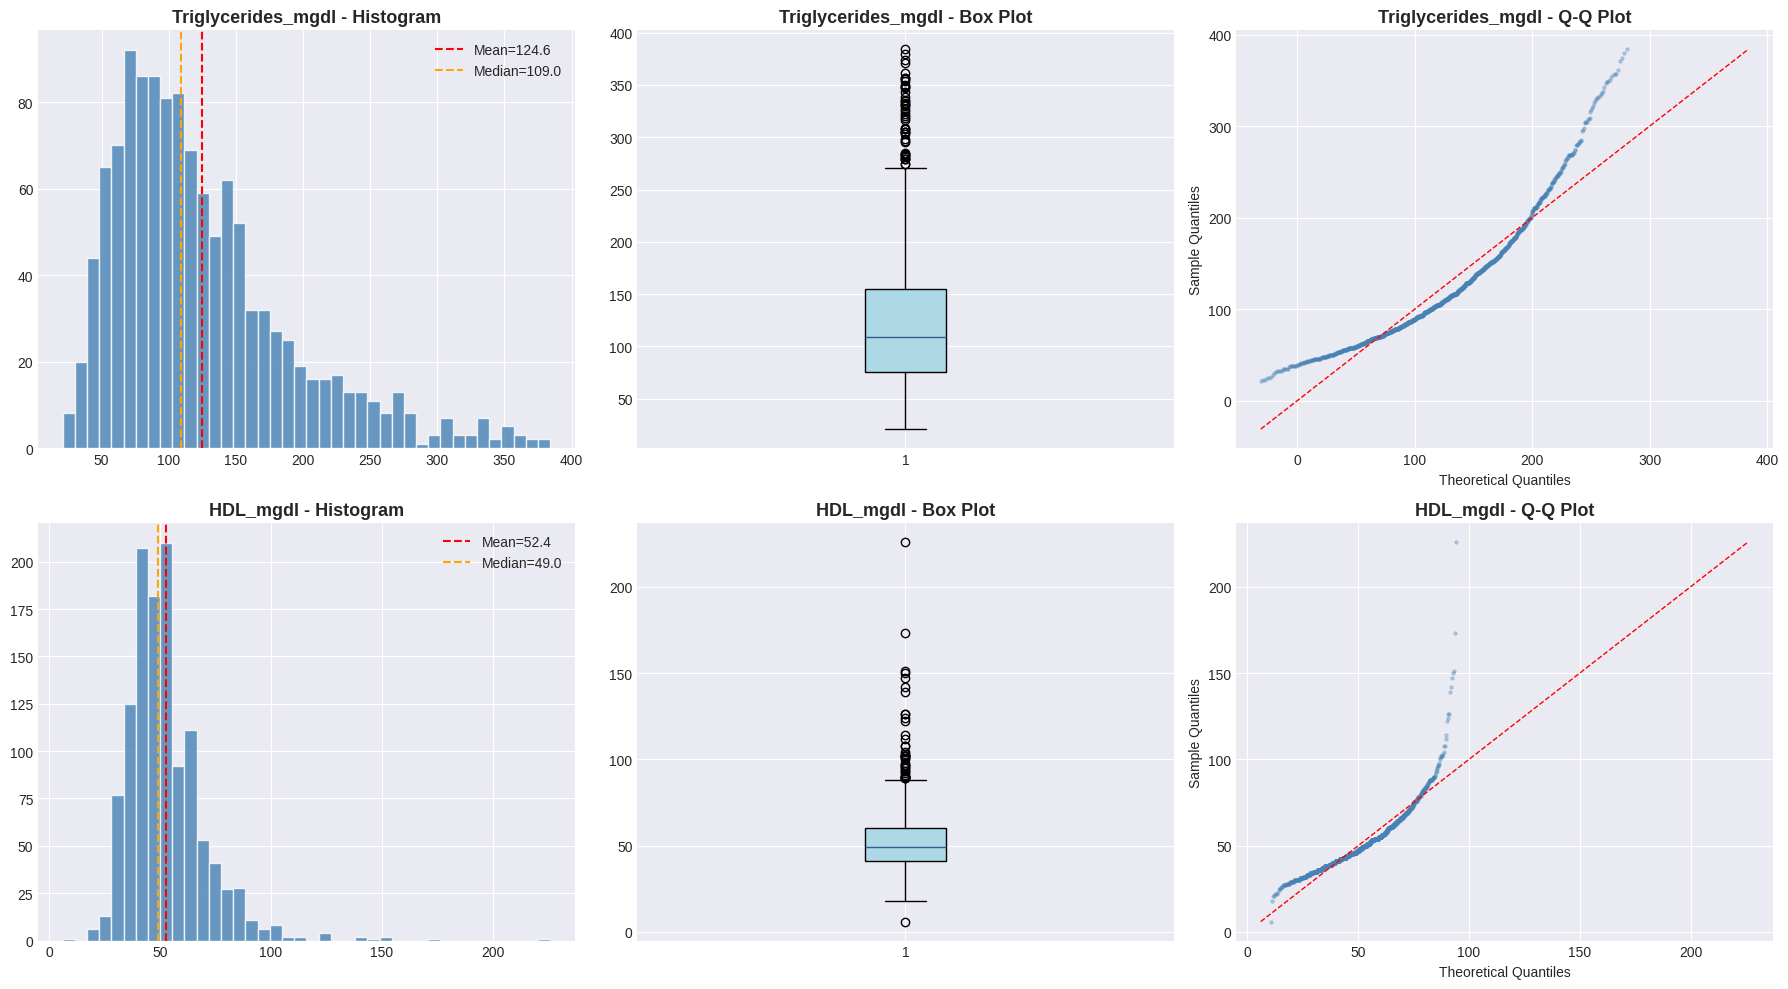

In [ ]:
# Visualize Target Variable Distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, target in enumerate(targets):
    # Histogram
    axes[i, 0].hist(df[target], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].axvline(df[target].mean(), color='red', linestyle='--', label=f'Mean={df[target].mean():.1f}')
    axes[i, 0].axvline(df[target].median(), color='orange', linestyle='--', label=f'Median={df[target].median():.1f}')
    axes[i, 0].set_title(f'{target} - Histogram', fontsize=13, fontweight='bold')
    axes[i, 0].legend()

    # Box plot
    axes[i, 1].boxplot(df[target], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
    axes[i, 1].set_title(f'{target} - Box Plot', fontsize=13, fontweight='bold')

    # QQ plot approximation (sorted values vs normal)
    sorted_vals = np.sort(df[target])
    norm_quantiles = np.linspace(0.01, 0.99, len(sorted_vals))
    from scipy import stats
    theoretical = stats.norm.ppf(norm_quantiles, loc=df[target].mean(), scale=df[target].std())
    axes[i, 2].scatter(theoretical, sorted_vals, alpha=0.3, s=5, color='steelblue')
    min_val = min(theoretical.min(), sorted_vals.min())
    max_val = max(theoretical.max(), sorted_vals.max())
    axes[i, 2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
    axes[i, 2].set_title(f'{target} - Q-Q Plot', fontsize=13, fontweight='bold')
    axes[i, 2].set_xlabel('Theoretical Quantiles')
    axes[i, 2].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.savefig('target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


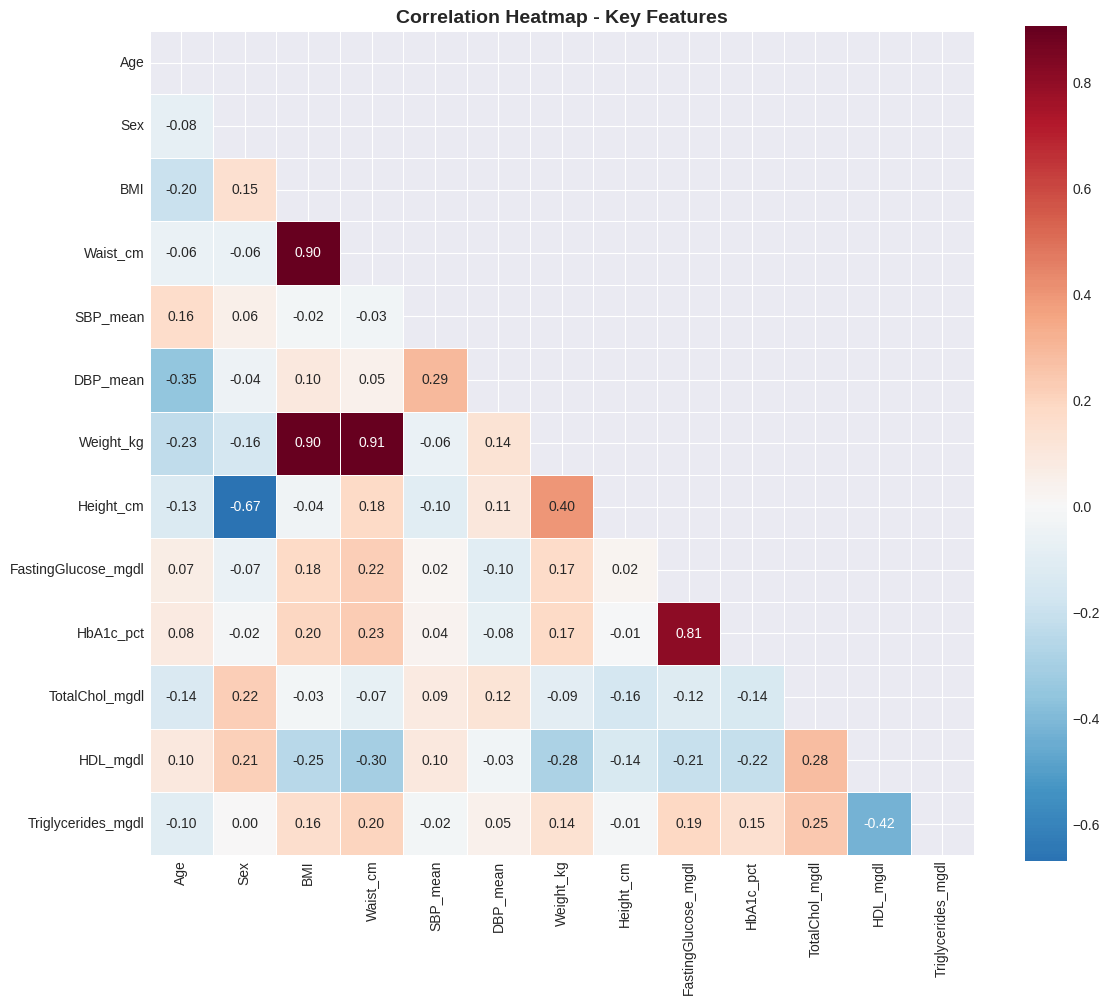

In [ ]:
# Correlation Heatmap of key features
key_features = ['Age', 'Sex', 'BMI', 'Waist_cm', 'SBP_mean', 'DBP_mean',
                'Weight_kg', 'Height_cm', 'FastingGlucose_mgdl', 'HbA1c_pct',
                'TotalChol_mgdl', 'HDL_mgdl', 'Triglycerides_mgdl']
fig, ax = plt.subplots(figsize=(12, 10))
corr = df[key_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap - Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 2. Data Cleaning

Based on our exploratory analysis, the following issues must be addressed:

1. **`DBP_mean ≈ 5.4e-79`** — 5 rows with impossible diastolic BP values (encoding error)  
2. **`SEQN = 92312`** — Both DBP and HDL (=6) are erroneous  
3. **`SMQ020`** — Constant column (all values = 1.0), zero variance  
4. **Derived columns** — `mets_*`, `MetS_*`, `CVD_high_risk`, `LDL_mgdl` cause data leakage  
5. **`SEQN`, `cycle`** — ID/metadata columns, not predictive


In [ ]:
# Data Cleaning
print(f"Original shape: {df.shape}")

# 1. Fix DBP_mean encoding errors (≈ 5.4e-79 -> NaN -> median impute)
dbp_mask = df['DBP_mean'] < 1.0
print(f"\n1. DBP_mean near-zero values: {dbp_mask.sum()} rows")
print(f"   Values: {df.loc[dbp_mask, 'DBP_mean'].values}")
dbp_median = df.loc[~dbp_mask, 'DBP_mean'].median()
df.loc[dbp_mask, 'DBP_mean'] = dbp_median
print(f"   Replaced with median: {dbp_median:.2f}")

# 2. Remove constant column SMQ020
print(f"\n2. SMQ020 unique values: {df['SMQ020'].unique()} -> Dropping (zero variance)")
df.drop(columns=['SMQ020'], inplace=True)

# 3. Remove ID and metadata columns
drop_id_cols = ['SEQN', 'cycle']
print(f"\n3. Dropping ID/metadata: {drop_id_cols}")
df.drop(columns=drop_id_cols, inplace=True)

# 4. Remove derived / leakage columns
leakage_cols = ['mets_waist', 'mets_tg', 'mets_hdl', 'mets_bp', 'mets_glu',
                'MetS_score', 'MetS_binary', 'CVD_high_risk',
                'Diabetes_binary', 'Diabetes_3class', 'LDL_mgdl']
print(f"\n4. Dropping leakage/derived columns: {leakage_cols}")
df.drop(columns=leakage_cols, inplace=True)

print(f"\nCleaned shape: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")


Original shape: (1213, 42)

1. DBP_mean near-zero values: 5 rows
   Values: [5.39760535e-79 5.39760535e-79 5.39760535e-79 5.39760535e-79
 5.39760535e-79]
   Replaced with median: 70.00

2. SMQ020 unique values: [1.] -> Dropping (zero variance)

3. Dropping ID/metadata: ['SEQN', 'cycle']

4. Dropping leakage/derived columns: ['mets_waist', 'mets_tg', 'mets_hdl', 'mets_bp', 'mets_glu', 'MetS_score', 'MetS_binary', 'CVD_high_risk', 'Diabetes_binary', 'Diabetes_3class', 'LDL_mgdl']

Cleaned shape: (1213, 28)
Remaining columns: ['Age', 'Sex', 'Race', 'Education', 'IncomeRatio', 'Weight_kg', 'Height_cm', 'BMI', 'Waist_cm', 'SBP_mean', 'DBP_mean', 'Kcal_day1', 'Protein_g_day1', 'Carbs_g_day1', 'Sugar_g_day1', 'Fiber_g_day1', 'Fat_g_day1', 'SatFat_g_day1', 'Sodium_mg_day1', 'DietChol_mg_day1', 'DIQ010', 'BPQ050A', 'SMQ040', 'FastingGlucose_mgdl', 'HbA1c_pct', 'TotalChol_mgdl', 'HDL_mgdl', 'Triglycerides_mgdl']


---
## 3. Preprocessing

**Applied Steps:**
- **Feature Scaling:** RobustScaler for features (handles outliers better than StandardScaler)
- **Target Transformation:** Log-transform for Triglycerides and HDL (right-skewed distributions)
- **Train/Test Split:** 80/20 with fixed random seed
- **Leakage control:** `TotalChol_mgdl` is kept for EDA only and excluded from model features because it is mathematically related to HDL and triglycerides
- Preprocessing is fitted ONLY on training data to prevent data leakage


In [ ]:
# Define feature groups
# Self-measured features (Config A)
self_measured = ['Age', 'Sex', 'Race', 'Education', 'IncomeRatio',
                 'Weight_kg', 'Height_cm', 'BMI', 'Waist_cm',
                 'SBP_mean', 'DBP_mean',
                 'DIQ010', 'BPQ050A', 'SMQ040',
                 'FastingGlucose_mgdl', 'HbA1c_pct']

# Dietary features (added in Config B)
dietary_features = ['Kcal_day1', 'Protein_g_day1', 'Carbs_g_day1', 'Sugar_g_day1',
                    'Fiber_g_day1', 'Fat_g_day1', 'SatFat_g_day1',
                    'Sodium_mg_day1', 'DietChol_mg_day1']

# Config B = self-measured + dietary
config_b_features = self_measured + dietary_features

# Target variables
target_cols = ['Triglycerides_mgdl', 'HDL_mgdl']

print("Configuration A (Self-measured only):", len(self_measured), "features")
print(self_measured)
print(f"\nConfiguration B (Self-measured + Dietary):", len(config_b_features), "features")
print(config_b_features)


Configuration A (Self-measured only): 16 features
['Age', 'Sex', 'Race', 'Education', 'IncomeRatio', 'Weight_kg', 'Height_cm', 'BMI', 'Waist_cm', 'SBP_mean', 'DBP_mean', 'DIQ010', 'BPQ050A', 'SMQ040', 'FastingGlucose_mgdl', 'HbA1c_pct']

Configuration B (Self-measured + Dietary): 25 features
['Age', 'Sex', 'Race', 'Education', 'IncomeRatio', 'Weight_kg', 'Height_cm', 'BMI', 'Waist_cm', 'SBP_mean', 'DBP_mean', 'DIQ010', 'BPQ050A', 'SMQ040', 'FastingGlucose_mgdl', 'HbA1c_pct', 'Kcal_day1', 'Protein_g_day1', 'Carbs_g_day1', 'Sugar_g_day1', 'Fiber_g_day1', 'Fat_g_day1', 'SatFat_g_day1', 'Sodium_mg_day1', 'DietChol_mg_day1']


In [ ]:
# 80/20 Train-Test Split (same split for ALL models)
X = df[config_b_features]
y_tg = df['Triglycerides_mgdl']
y_hdl = df['HDL_mgdl']

# Store Sex for threshold evaluation later
sex_series = df['Sex'].copy()

X_train, X_test, y_tg_train, y_tg_test, y_hdl_train, y_hdl_test, sex_train, sex_test = \
    train_test_split(X, y_tg, y_hdl, sex_series,
                     test_size=0.2, random_state=RANDOM_STATE)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"Train/Test ratio: {X_train.shape[0]/len(X)*100:.0f}/{X_test.shape[0]/len(X)*100:.0f}")


Train set: 970 samples
Test set:  243 samples
Train/Test ratio: 80/20


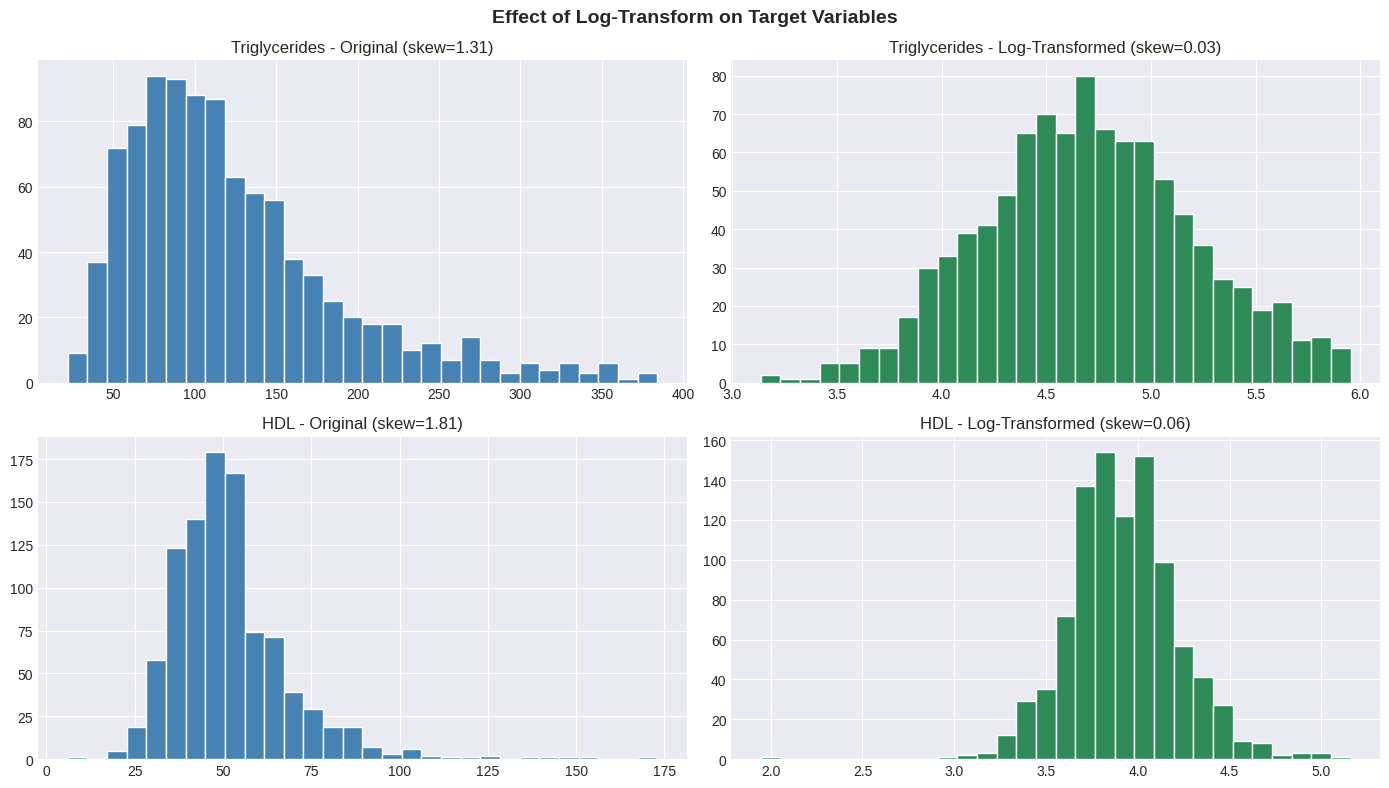

Log-transform applied to reduce skewness of target variables.
Models will predict log-transformed values; predictions will be inverse-transformed via expm1().


In [ ]:
# Log-transform target variables (to handle right skew)
# We use log1p for safety (log(1+x))
y_tg_train_log = np.log1p(y_tg_train)
y_tg_test_log = np.log1p(y_tg_test)
y_hdl_train_log = np.log1p(y_hdl_train)
y_hdl_test_log = np.log1p(y_hdl_test)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (name, orig, logged) in enumerate([
    ('Triglycerides', y_tg_train, y_tg_train_log),
    ('HDL', y_hdl_train, y_hdl_train_log)
]):
    axes[i, 0].hist(orig, bins=30, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{name} - Original (skew={orig.skew():.2f})')
    axes[i, 1].hist(logged, bins=30, color='seagreen', edgecolor='white')
    axes[i, 1].set_title(f'{name} - Log-Transformed (skew={logged.skew():.2f})')

plt.suptitle('Effect of Log-Transform on Target Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('log_transform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Log-transform applied to reduce skewness of target variables.")
print("Models will predict log-transformed values; predictions will be inverse-transformed via expm1().")


---
## 4. Feature Engineering

Creating **10 engineered features** based on medical/physiological reasoning, including the feature ideas from the `metabolic 2` presentation:

| # | Feature | Reasoning |
|---|---------|-----------|
| 1 | `BMI_squared` | Non-linear BMI effect on metabolic markers |
| 2 | `Waist_Height_Ratio` | Better central obesity indicator than waist alone |
| 3 | `BMI_Age_Interaction` | Metabolic risk increases with age×obesity interaction |
| 4 | `MAP` | Mean Arterial Pressure — better hemodynamic measure |
| 5 | `Pulse_Pressure` | SBP-DBP — arterial stiffness indicator |
| 6 | `Glucose_HbA1c_Ratio` | Captures acute vs chronic glycemic control |
| 7 | `Sugar_Fiber_Ratio` | Dietary quality signal from high sugar relative to protective fiber |
| 8 | `SatFat_TotalFat_Ratio` | Fat quality signal from saturated fat share in total fat |
| 9 | `Calorie_Norm_Fat` | Fat intake per 1000 kcal — diet quality metric |
| 10 | `Fat_Carb_Ratio` | Macronutrient balance ratio |


In [ ]:
# Feature Engineering function (applied to both train and test)
def engineer_features(X_df):
    X = X_df.copy()

    # 1. BMI squared — non-linear metabolic risk
    X['BMI_squared'] = X['BMI'] ** 2

    # 2. Waist-to-Height Ratio — central obesity indicator
    X['Waist_Height_Ratio'] = X['Waist_cm'] / X['Height_cm']

    # 3. BMI × Age interaction — metabolic risk amplified with age
    X['BMI_Age_Interaction'] = X['BMI'] * X['Age']

    # 4. Mean Arterial Pressure (MAP = DBP + 1/3*(SBP-DBP))
    X['MAP'] = X['DBP_mean'] + (X['SBP_mean'] - X['DBP_mean']) / 3

    # 5. Pulse Pressure (SBP - DBP) — arterial stiffness
    X['Pulse_Pressure'] = X['SBP_mean'] - X['DBP_mean']

    # 6. Glucose / HbA1c ratio — acute vs chronic glycemic state
    X['Glucose_HbA1c_Ratio'] = X['FastingGlucose_mgdl'] / (X['HbA1c_pct'] + 1e-8)

    # 7. Sugar to Fiber Ratio - presentation feature; higher values imply poorer dietary quality
    if 'Sugar_g_day1' in X.columns and 'Fiber_g_day1' in X.columns:
        fiber_denom = X['Fiber_g_day1'].clip(lower=1.0)
        X['Sugar_Fiber_Ratio'] = X['Sugar_g_day1'] / fiber_denom
    else:
        X['Sugar_Fiber_Ratio'] = 0

    # 8. Saturated Fat to Total Fat Ratio - presentation feature; captures fat quality
    if 'SatFat_g_day1' in X.columns and 'Fat_g_day1' in X.columns:
        fat_denom = X['Fat_g_day1'].clip(lower=1.0)
        X['SatFat_TotalFat_Ratio'] = X['SatFat_g_day1'] / fat_denom
    else:
        X['SatFat_TotalFat_Ratio'] = 0

    # 9. Calorie-Normalized Fat Intake (per 1000 kcal) — diet quality
    if 'Kcal_day1' in X.columns and 'Fat_g_day1' in X.columns:
        X['Calorie_Norm_Fat'] = X['Fat_g_day1'] / (X['Kcal_day1'] / 1000 + 1e-8)
    else:
        X['Calorie_Norm_Fat'] = 0

    # 10. Fat to Carbohydrate Ratio — macronutrient balance
    if 'Fat_g_day1' in X.columns and 'Carbs_g_day1' in X.columns:
        X['Fat_Carb_Ratio'] = X['Fat_g_day1'] / (X['Carbs_g_day1'] + 1e-8)
    else:
        X['Fat_Carb_Ratio'] = 0

    return X

engineered_feature_names = ['BMI_squared', 'Waist_Height_Ratio', 'BMI_Age_Interaction',
                             'MAP', 'Pulse_Pressure', 'Glucose_HbA1c_Ratio',
                             'Sugar_Fiber_Ratio', 'SatFat_TotalFat_Ratio',
                             'Calorie_Norm_Fat', 'Fat_Carb_Ratio']

# Apply feature engineering
X_train_eng = engineer_features(X_train)
X_test_eng = engineer_features(X_test)

print(f"Features after engineering: {X_train_eng.shape[1]}")
print(f"New features: {engineered_feature_names}")
print(f"\nEngineered feature statistics (train):")
X_train_eng[engineered_feature_names].describe().T


Features after engineering: 35
New features: ['BMI_squared', 'Waist_Height_Ratio', 'BMI_Age_Interaction', 'MAP', 'Pulse_Pressure', 'Glucose_HbA1c_Ratio', 'Sugar_Fiber_Ratio', 'SatFat_TotalFat_Ratio', 'Calorie_Norm_Fat', 'Fat_Carb_Ratio']

Engineered feature statistics (train):


,count,mean,std,min,25%,50%,75%,max
BMI_squared,970.00,1025.38,525.72,299.29,676.00,888.04,1218.01,3969.00
Waist_Height_Ratio,970.00,0.64,0.10,0.39,0.57,0.62,0.70,1.01
BMI_Age_Interaction,970.00,1880.89,542.39,439.30,1512.53,1850.05,2210.75,4065.60
MAP,970.00,90.72,13.19,46.22,82.67,89.78,98.83,136.89
Pulse_Pressure,970.00,62.86,21.39,20.67,47.33,59.00,74.00,154.67
Glucose_HbA1c_Ratio,970.00,19.43,3.56,7.73,17.23,18.86,20.81,42.37
Sugar_Fiber_Ratio,970.00,9.31,11.82,0.05,3.77,6.22,11.31,155.93
SatFat_TotalFat_Ratio,970.00,0.32,0.08,0.14,0.27,0.32,0.37,0.68
Calorie_Norm_Fat,970.00,39.13,10.78,5.48,32.42,39.42,46.15,69.77
Fat_Carb_Ratio,970.00,0.37,0.21,0.03,0.24,0.33,0.45,2.25


---
## 5. Feature Configurations & Scaling Pipeline

**Two configurations evaluated:**
- **Config A:** Self-measured features only (16 original + 6 engineered that don't need dietary data)
- **Config B:** Self-measured + Dietary features (25 original + 10 engineered)

Within each config, three feature sets are compared:
1. Original features only
2. Original + Engineered features
3. Reduced feature set (after feature selection)


In [ ]:
# Build feature sets for both configurations
# Config A features (no dietary)
config_a_orig_cols = [c for c in self_measured if c in X_train.columns]
config_a_eng_cols = config_a_orig_cols + ['BMI_squared', 'Waist_Height_Ratio',
                     'BMI_Age_Interaction', 'MAP', 'Pulse_Pressure', 'Glucose_HbA1c_Ratio']

# Config B features (all)
config_b_orig_cols = [c for c in config_b_features if c in X_train.columns]
config_b_eng_cols = config_b_orig_cols + engineered_feature_names

# Prepare datasets dict for systematic evaluation
datasets = {}

# Config A - Original
datasets['A_orig'] = {
    'X_train': X_train[config_a_orig_cols].copy(),
    'X_test': X_test[config_a_orig_cols].copy(),
    'label': 'Config A - Original'
}
# Config A - Engineered
datasets['A_eng'] = {
    'X_train': X_train_eng[config_a_eng_cols].copy(),
    'X_test': X_test_eng[config_a_eng_cols].copy(),
    'label': 'Config A - Engineered'
}
# Config B - Original
datasets['B_orig'] = {
    'X_train': X_train[config_b_orig_cols].copy(),
    'X_test': X_test[config_b_orig_cols].copy(),
    'label': 'Config B - Original'
}
# Config B - Engineered
datasets['B_eng'] = {
    'X_train': X_train_eng[config_b_eng_cols].copy(),
    'X_test': X_test_eng[config_b_eng_cols].copy(),
    'label': 'Config B - Engineered'
}

for key, d in datasets.items():
    print(f"{d['label']}: {d['X_train'].shape[1]} features")


Config A - Original: 16 features
Config A - Engineered: 22 features
Config B - Original: 25 features
Config B - Engineered: 35 features


In [ ]:
# Scale all datasets (fit on train only!)
scaled_datasets = {}
scalers = {}

for key, d in datasets.items():
    scaler = RobustScaler()
    X_tr_scaled = pd.DataFrame(
        scaler.fit_transform(d['X_train']),
        columns=d['X_train'].columns,
        index=d['X_train'].index
    )
    X_te_scaled = pd.DataFrame(
        scaler.transform(d['X_test']),
        columns=d['X_test'].columns,
        index=d['X_test'].index
    )
    scaled_datasets[key] = {
        'X_train': X_tr_scaled,
        'X_test': X_te_scaled,
        'label': d['label']
    }
    scalers[key] = scaler

print("All feature sets scaled with RobustScaler (fitted on train only).")


All feature sets scaled with RobustScaler (fitted on train only).


---
## 6. Feature Reduction / Selection

Two methods applied inside the training pipeline (no data leakage):
1. **PCA** — Variance-based dimensionality reduction
2. **Tree-based Feature Importance** — Using Random Forest to select top features


In [ ]:
# Feature Selection using Random Forest Importance (on train only)
from sklearn.ensemble import RandomForestRegressor

def select_features_rf(X_train, y_train, X_test, n_top=15, target_name='target'):
    """Select top-n features using RF importance (fitted on train only)."""
    rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1)
    rf.fit(X_train, y_train)
    importances = pd.Series(rf.feature_importances_, index=X_train.columns)
    top_features = importances.nlargest(n_top).index.tolist()
    print(f"  Top {n_top} features for {target_name}: {top_features}")
    return X_train[top_features], X_test[top_features], top_features

# Apply feature selection on Config B Engineered (largest feature set)
print("Feature Selection for Triglycerides:")
X_tr_tg_reduced, X_te_tg_reduced, tg_top_feats = select_features_rf(
    scaled_datasets['B_eng']['X_train'], y_tg_train_log,
    scaled_datasets['B_eng']['X_test'], n_top=15, target_name='Triglycerides'
)

print("\nFeature Selection for HDL:")
X_tr_hdl_reduced, X_te_hdl_reduced, hdl_top_feats = select_features_rf(
    scaled_datasets['B_eng']['X_train'], y_hdl_train_log,
    scaled_datasets['B_eng']['X_test'], n_top=15, target_name='HDL'
)

# Add reduced feature sets to datasets
scaled_datasets['B_reduced_tg'] = {
    'X_train': X_tr_tg_reduced, 'X_test': X_te_tg_reduced,
    'label': 'Config B - Reduced (TG-optimized)'
}
scaled_datasets['B_reduced_hdl'] = {
    'X_train': X_tr_hdl_reduced, 'X_test': X_te_hdl_reduced,
    'label': 'Config B - Reduced (HDL-optimized)'
}


Feature Selection for Triglycerides:
  Top 15 features for Triglycerides: ['Waist_Height_Ratio', 'Race', 'FastingGlucose_mgdl', 'HbA1c_pct', 'Age', 'SatFat_TotalFat_Ratio', 'BMI_Age_Interaction', 'Height_cm', 'Glucose_HbA1c_Ratio', 'DietChol_mg_day1', 'Waist_cm', 'IncomeRatio', 'Weight_kg', 'MAP', 'Sugar_Fiber_Ratio']

Feature Selection for HDL:
  Top 15 features for HDL: ['Weight_kg', 'Waist_cm', 'HbA1c_pct', 'FastingGlucose_mgdl', 'SatFat_TotalFat_Ratio', 'Glucose_HbA1c_Ratio', 'Age', 'Sugar_Fiber_Ratio', 'Height_cm', 'IncomeRatio', 'DietChol_mg_day1', 'Sugar_g_day1', 'Waist_Height_Ratio', 'Sex', 'BMI_Age_Interaction']


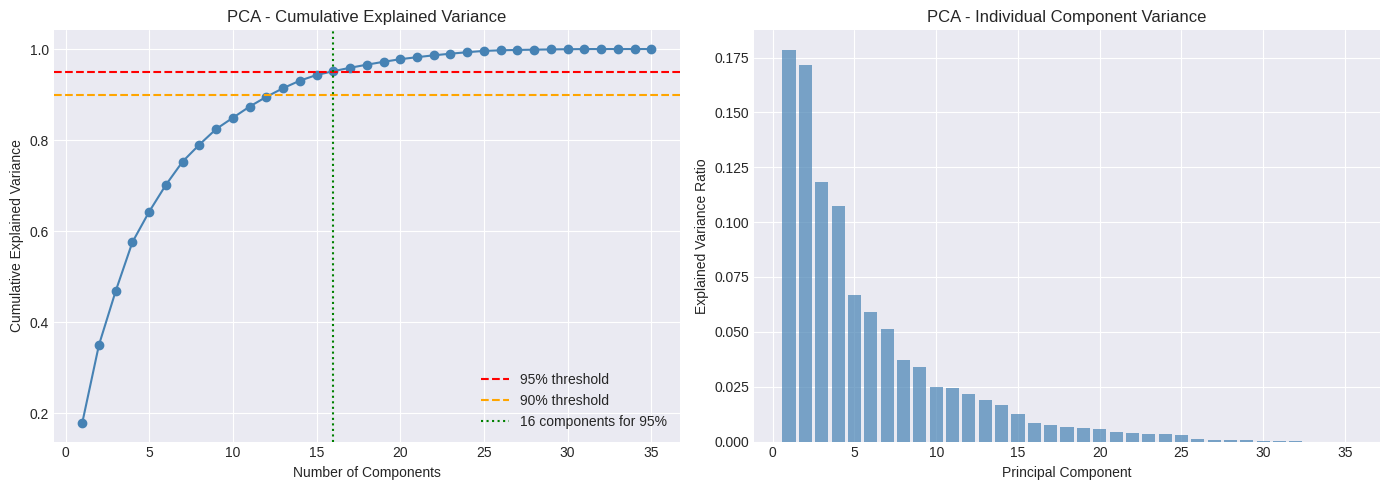

Components needed for 90% variance: 13
Components needed for 95% variance: 16


In [ ]:
# PCA Analysis on Config B Engineered
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(scaled_datasets['B_eng']['X_train'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[0].plot(range(1, len(cumvar)+1), cumvar, 'o-', color='steelblue')
axes[0].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[0].axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
n_95 = np.argmax(cumvar >= 0.95) + 1
axes[0].axvline(x=n_95, color='green', linestyle=':', label=f'{n_95} components for 95%')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA - Cumulative Explained Variance')
axes[0].legend()

# Individual component variance
axes[1].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('PCA - Individual Component Variance')

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Components needed for 90% variance: {np.argmax(cumvar >= 0.90) + 1}")
print(f"Components needed for 95% variance: {n_95}")


---
## 7. Regression Models, Ensemble Methods & Hyperparameter Optimization

### Models Trained:
1. **Linear Regression** (Baseline)
2. **Ridge Regression**
3. **Lasso Regression**
4. **Random Forest Regressor**
5. **Gradient Boosting Regressor**
6. **XGBoost Regressor**

### Ensemble:
7. **Stacking Regressor** (Ridge + RF + XGBoost → Linear meta-learner)

All models use **5-Fold Cross-Validation** on training set for hyperparameter tuning via GridSearchCV.


In [ ]:
# Define models and hyperparameter grids
def get_models_and_params():
    models = {
        'Linear Regression': {
            'model': LinearRegression(),
            'params': {}  # Baseline, no tuning
        },
        'Ridge': {
            'model': Ridge(random_state=RANDOM_STATE),
            'params': {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
        },
        'Lasso': {
            'model': Lasso(random_state=RANDOM_STATE, max_iter=5000),
            'params': {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
        },
        'Random Forest': {
            'model': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
            'params': {
                'n_estimators': [120],
                'max_depth': [8, None],
                'min_samples_split': [2, 5]
            }
        },
        'Gradient Boosting': {
            'model': GradientBoostingRegressor(random_state=RANDOM_STATE),
            'params': {
                'n_estimators': [120, 180],
                'max_depth': [2, 3],
                'learning_rate': [0.04, 0.08]
            }
        },
        'XGBoost': {
            'model': XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, verbosity=0, subsample=0.85, colsample_bytree=0.85),
            'params': {
                'n_estimators': [120, 180],
                'max_depth': [2, 3],
                'learning_rate': [0.04, 0.08]
            }
        }
    }
    return models

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Models and hyperparameter grids defined.")
print("5-Fold Cross-Validation will be used for tuning.")


Models and hyperparameter grids defined.
5-Fold Cross-Validation will be used for tuning.


In [ ]:
# Master training function
def train_and_evaluate(X_train, X_test, y_train_log, y_test_log, y_test_orig, target_name):
    """Train all models, tune hyperparameters, evaluate, return results."""
    models = get_models_and_params()
    results = []

    best_estimators = {}

    def cv_rmse_original_scale(model):
        """Report CV RMSE after converting log-target predictions back to mg/dL."""
        from sklearn.base import clone
        cv_rmses = []
        y_train_orig = np.expm1(y_train_log)
        for train_idx, val_idx in kfold.split(X_train):
            m = clone(model)
            X_cv_train = X_train.iloc[train_idx]
            X_cv_val = X_train.iloc[val_idx]
            y_cv_train_log = y_train_log.iloc[train_idx]
            y_cv_val_orig = y_train_orig.iloc[val_idx]
            m.fit(X_cv_train, y_cv_train_log)
            y_cv_pred = np.expm1(m.predict(X_cv_val))
            y_cv_pred = np.clip(y_cv_pred, 0, None)
            cv_rmses.append(np.sqrt(mean_squared_error(y_cv_val_orig, y_cv_pred)))
        return np.mean(cv_rmses), np.std(cv_rmses)

    for name, config in models.items():
        print(f"  Training {name}...")
        start = time.time()

        if config['params']:
            grid = GridSearchCV(config['model'], config['params'],
                                cv=kfold, scoring='neg_root_mean_squared_error',
                                n_jobs=1, refit=True)
            grid.fit(X_train, y_train_log)
            best_model = grid.best_estimator_
            best_params = grid.best_params_
        else:
            best_model = config['model']
            best_model.fit(X_train, y_train_log)
            best_params = {}

        train_time = time.time() - start

        # Predict (log space)
        y_pred_log = best_model.predict(X_test)

        # Inverse transform to original scale
        y_pred = np.expm1(y_pred_log)
        y_true = y_test_orig

        # Metrics in original scale
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        cv_rmse_mean, cv_rmse_std = cv_rmse_original_scale(best_model)

        results.append({
            'Model': name,
            'Target': target_name,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'CV_RMSE_mean': cv_rmse_mean,
            'CV_RMSE_std': cv_rmse_std,
            'Train_Time_s': train_time,
            'Best_Params': str(best_params)
        })

        best_estimators[name] = best_model

    # -------- ENSEMBLE: Stacking Regressor --------
    print("  Training Stacking Ensemble...")
    start = time.time()

    stacking = StackingRegressor(
        estimators=[
            ('ridge', best_estimators.get('Ridge', Ridge(alpha=1.0))),
            ('rf', best_estimators.get('Random Forest', RandomForestRegressor(random_state=RANDOM_STATE))),
            ('xgb', best_estimators.get('XGBoost', XGBRegressor(random_state=RANDOM_STATE, verbosity=0)))
        ],
        final_estimator=LinearRegression(),
        cv=kfold, n_jobs=1
    )
    stacking.fit(X_train, y_train_log)
    train_time = time.time() - start

    y_pred_log_stack = stacking.predict(X_test)
    y_pred_stack = np.expm1(y_pred_log_stack)

    cv_rmse_stack_mean, cv_rmse_stack_std = cv_rmse_original_scale(stacking)

    results.append({
        'Model': 'Stacking Ensemble',
        'Target': target_name,
        'RMSE': np.sqrt(mean_squared_error(y_test_orig, y_pred_stack)),
        'MAE': mean_absolute_error(y_test_orig, y_pred_stack),
        'R2': r2_score(y_test_orig, y_pred_stack),
        'CV_RMSE_mean': cv_rmse_stack_mean,
        'CV_RMSE_std': cv_rmse_stack_std,
        'Train_Time_s': train_time,
        'Best_Params': 'Ridge+RF+XGB->LR'
    })

    best_estimators['Stacking Ensemble'] = stacking

    return pd.DataFrame(results), best_estimators


In [ ]:
# ==================== TRAIN ON CONFIG B - ENGINEERED ====================
print("="*60)
print("TRAINING ON CONFIG B - ENGINEERED FEATURES")
print("="*60)

print("\n--- Triglycerides ---")
results_tg, models_tg = train_and_evaluate(
    scaled_datasets['B_eng']['X_train'], scaled_datasets['B_eng']['X_test'],
    y_tg_train_log, y_tg_test_log, y_tg_test, 'Triglycerides'
)

print("\n--- HDL Cholesterol ---")
results_hdl, models_hdl = train_and_evaluate(
    scaled_datasets['B_eng']['X_train'], scaled_datasets['B_eng']['X_test'],
    y_hdl_train_log, y_hdl_test_log, y_hdl_test, 'HDL'
)

all_results = pd.concat([results_tg, results_hdl], ignore_index=True)
print("\nTraining complete!")


TRAINING ON CONFIG B - ENGINEERED FEATURES

--- Triglycerides ---
  Training Linear Regression...
  Training Ridge...
  Training Lasso...
  Training Random Forest...
  Training Gradient Boosting...
  Training XGBoost...
  Training Stacking Ensemble...

--- HDL Cholesterol ---
  Training Linear Regression...
  Training Ridge...
  Training Lasso...
  Training Random Forest...
  Training Gradient Boosting...
  Training XGBoost...
  Training Stacking Ensemble...

Training complete!


In [ ]:
# Display Triglycerides Results
print("TRIGLYCERIDES PREDICTION RESULTS (Config B - Engineered)")
print("="*70)
display_cols = ['Model', 'RMSE', 'MAE', 'R2', 'CV_RMSE_mean', 'CV_RMSE_std', 'Train_Time_s']
print(results_tg[display_cols].to_string(index=False, float_format='{:.4f}'.format))


TRIGLYCERIDES PREDICTION RESULTS (Config B - Engineered)
            Model    RMSE     MAE     R2  CV_RMSE_mean  CV_RMSE_std  Train_Time_s
Linear Regression 65.1439 48.5533 0.0502       65.2841       5.3831        0.0305
            Ridge 64.6811 48.2420 0.0637       65.0453       5.6743        0.5273
            Lasso 64.6218 48.1937 0.0654       65.0197       5.6885        0.4794
    Random Forest 63.9123 47.7995 0.0858       64.5402       5.2917       68.5994
Gradient Boosting 64.2871 48.2660 0.0750       64.7358       5.2056       71.1944
          XGBoost 63.8376 47.6144 0.0879       64.2817       5.5813        6.5539
Stacking Ensemble 63.4551 47.4715 0.0988       64.1908       5.7731       18.8979


In [ ]:
# Display HDL Results
print("\nHDL CHOLESTEROL PREDICTION RESULTS (Config B - Engineered)")
print("="*70)
print(results_hdl[display_cols].to_string(index=False, float_format='{:.4f}'.format))



HDL CHOLESTEROL PREDICTION RESULTS (Config B - Engineered)
            Model    RMSE     MAE     R2  CV_RMSE_mean  CV_RMSE_std  Train_Time_s
Linear Regression 18.8176 12.1404 0.1678       15.3938       1.7363        0.0037
            Ridge 19.0746 12.2775 0.1449       15.3283       1.6635        0.2872
            Lasso 18.9971 12.1985 0.1518       15.3238       1.7389        0.2749
    Random Forest 19.3894 12.4261 0.1164       15.1627       1.5245       69.9411
Gradient Boosting 19.4230 12.5208 0.1134       15.4662       1.5477       69.6059
          XGBoost 19.3273 12.3573 0.1221       15.2011       1.5772        6.4877
Stacking Ensemble 19.0507 12.1767 0.1470       15.0373       1.5870       19.4984


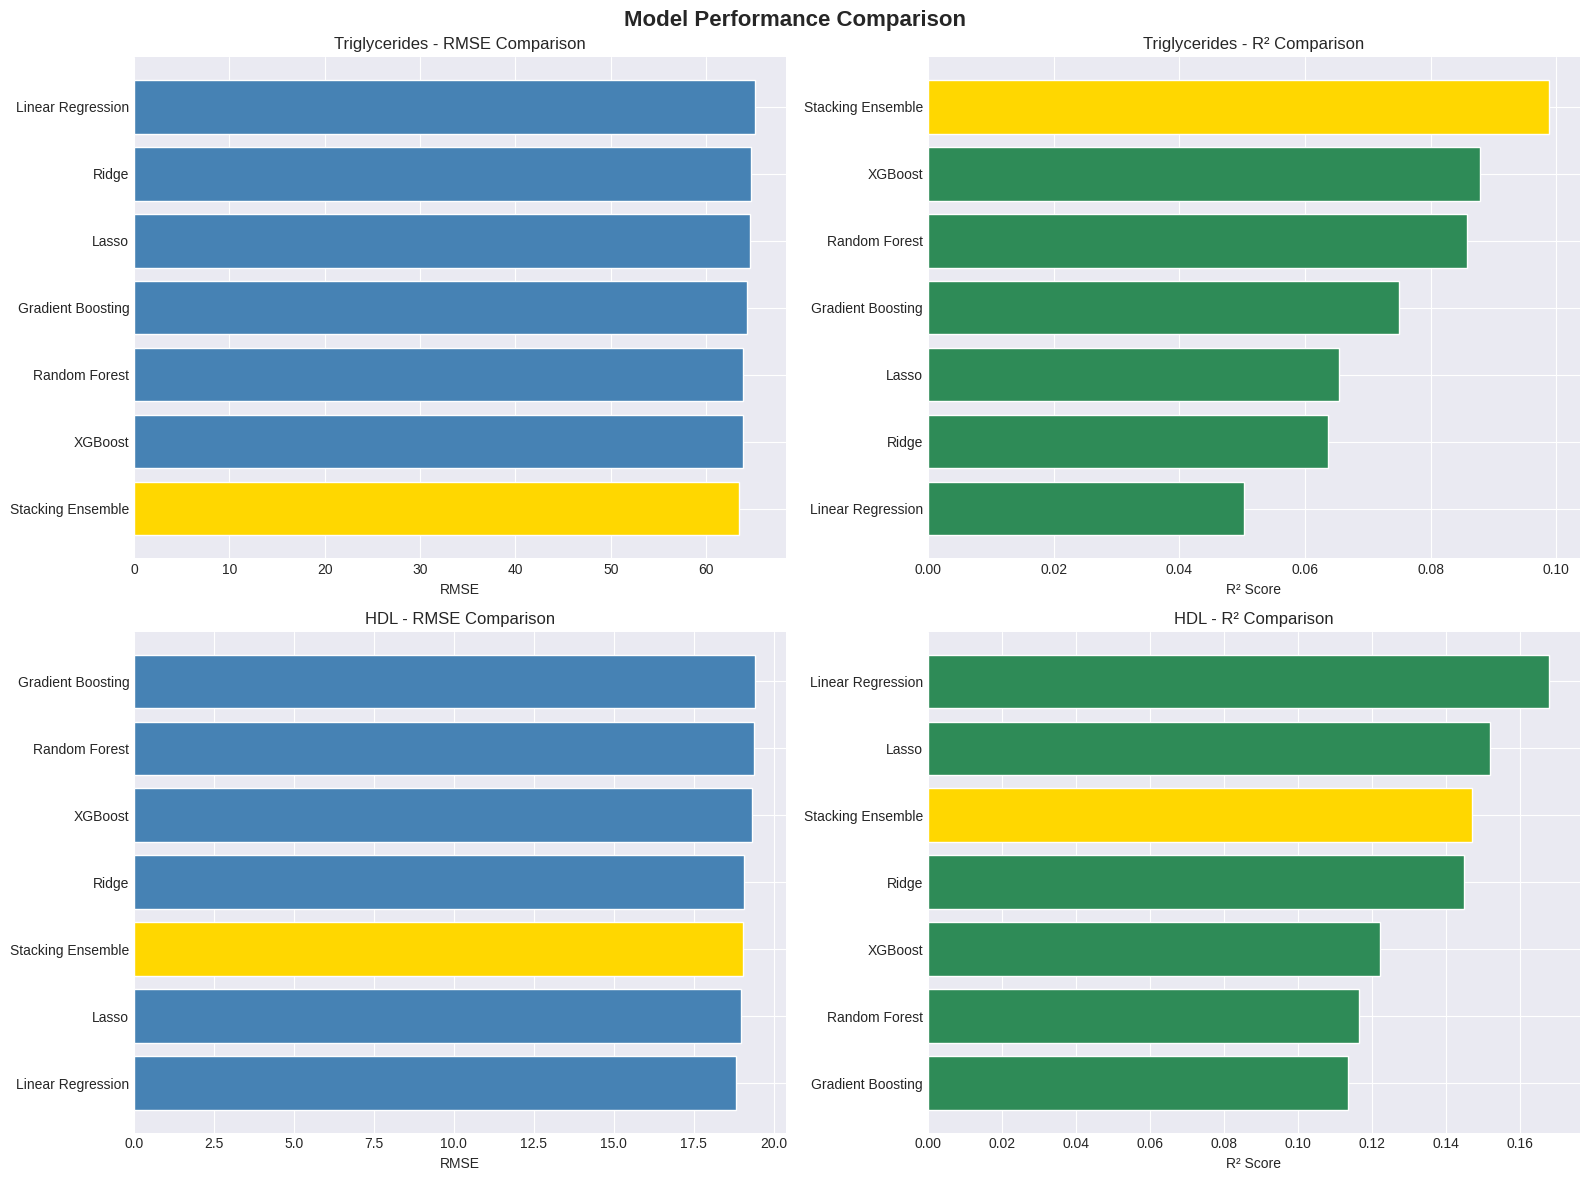

In [ ]:
# Visualization: Model Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, (res, target_name) in enumerate([(results_tg, 'Triglycerides'), (results_hdl, 'HDL')]):
    # RMSE comparison
    res_sorted = res.sort_values('RMSE')
    colors = ['gold' if m == 'Stacking Ensemble' else 'steelblue' for m in res_sorted['Model']]
    axes[i, 0].barh(res_sorted['Model'], res_sorted['RMSE'], color=colors, edgecolor='white')
    axes[i, 0].set_xlabel('RMSE')
    axes[i, 0].set_title(f'{target_name} - RMSE Comparison')

    # R² comparison
    res_sorted_r2 = res.sort_values('R2')
    colors_r2 = ['gold' if m == 'Stacking Ensemble' else 'seagreen' for m in res_sorted_r2['Model']]
    axes[i, 1].barh(res_sorted_r2['Model'], res_sorted_r2['R2'], color=colors_r2, edgecolor='white')
    axes[i, 1].set_xlabel('R² Score')
    axes[i, 1].set_title(f'{target_name} - R² Comparison')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Feature Importance

Analyzing which features contribute most to Triglycerides and HDL prediction using:
1. **Random Forest Feature Importance** (mean decrease in impurity)
2. **Permutation Importance** (model-agnostic)


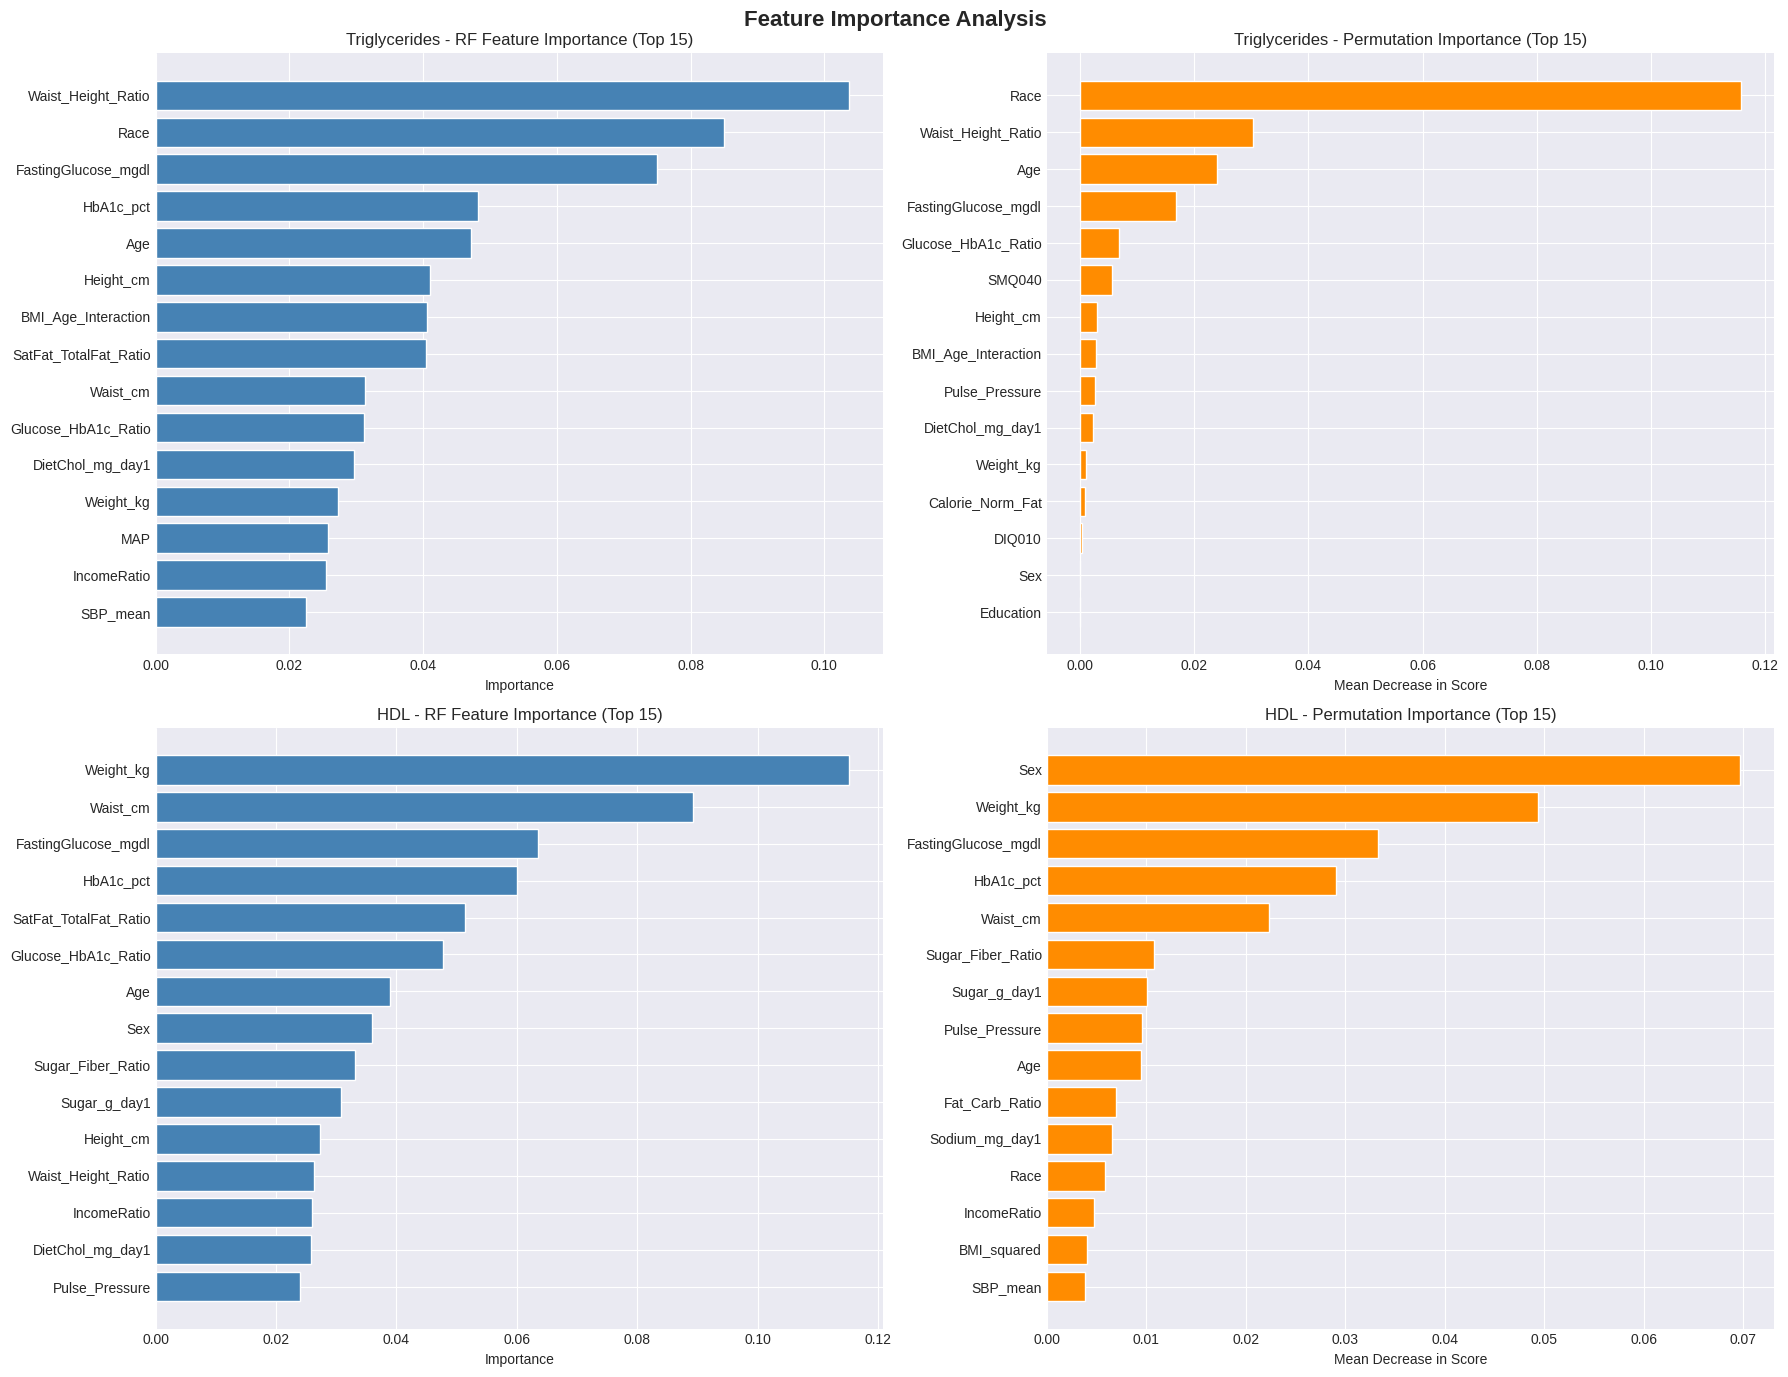

In [ ]:
# Feature Importance Analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for i, (target_name, models_dict, y_test_log) in enumerate([
    ('Triglycerides', models_tg, y_tg_test_log),
    ('HDL', models_hdl, y_hdl_test_log)
]):
    rf_model = models_dict['Random Forest']
    X_test_data = scaled_datasets['B_eng']['X_test']

    # 1. RF Feature Importance
    importance = pd.Series(rf_model.feature_importances_,
                           index=X_test_data.columns).sort_values(ascending=True)
    top15 = importance.tail(15)
    axes[i, 0].barh(top15.index, top15.values, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{target_name} - RF Feature Importance (Top 15)')
    axes[i, 0].set_xlabel('Importance')

    # 2. Permutation Importance
    perm_imp = permutation_importance(rf_model, X_test_data, y_test_log,
                                       n_repeats=10, random_state=RANDOM_STATE, n_jobs=1)
    perm_series = pd.Series(perm_imp.importances_mean,
                            index=X_test_data.columns).sort_values(ascending=True)
    top15_perm = perm_series.tail(15)
    axes[i, 1].barh(top15_perm.index, top15_perm.values, color='darkorange', edgecolor='white')
    axes[i, 1].set_title(f'{target_name} - Permutation Importance (Top 15)')
    axes[i, 1].set_xlabel('Mean Decrease in Score')

plt.suptitle('Feature Importance Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Medical Threshold Evaluation

Evaluating whether regression predictions can reliably detect medically important thresholds:
- **Triglycerides risk:** > 150 mg/dL
- **Low HDL:** Men < 40 mg/dL, Women < 50 mg/dL

From predicted biomarker values, classify individuals as above/below threshold, then compute:
- Threshold Detection **Accuracy**
- **Sensitivity** (true positive rate)
- **Specificity** (true negative rate)


In [ ]:
# Medical Threshold Evaluation
def evaluate_threshold_tg(y_true, y_pred, threshold=150):
    """Evaluate Triglycerides threshold detection."""
    true_labels = (y_true > threshold).astype(int)
    pred_labels = (y_pred > threshold).astype(int)

    acc = accuracy_score(true_labels, pred_labels)
    # Sensitivity = recall for positive class (above threshold)
    sensitivity = recall_score(true_labels, pred_labels, zero_division=0)
    # Specificity = recall for negative class (below threshold)
    tn, fp, fn, tp = confusion_matrix(true_labels, pred_labels).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return acc, sensitivity, specificity

def evaluate_threshold_hdl(y_true, y_pred, sex_values):
    """Evaluate HDL threshold detection (sex-dependent)."""
    # Men (Sex=1): low HDL < 40, Women (Sex=2): low HDL < 50
    thresholds = sex_values.map({1.0: 40, 2.0: 50})
    true_labels = (y_true < thresholds).astype(int)
    pred_labels = (y_pred < thresholds).astype(int)

    acc = accuracy_score(true_labels, pred_labels)
    sensitivity = recall_score(true_labels, pred_labels, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(true_labels, pred_labels).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return acc, sensitivity, specificity

# Evaluate all models on medical thresholds
threshold_results = []
X_test_data = scaled_datasets['B_eng']['X_test']

for model_name, model in models_tg.items():
    y_pred_log = model.predict(X_test_data)
    y_pred = np.expm1(y_pred_log)
    acc, sens, spec = evaluate_threshold_tg(y_tg_test.values, y_pred)
    threshold_results.append({
        'Model': model_name, 'Target': 'Triglycerides (>150)',
        'Accuracy': acc, 'Sensitivity': sens, 'Specificity': spec
    })

for model_name, model in models_hdl.items():
    y_pred_log = model.predict(X_test_data)
    y_pred = np.expm1(y_pred_log)
    acc, sens, spec = evaluate_threshold_hdl(y_hdl_test.values, y_pred, sex_test)
    threshold_results.append({
        'Model': model_name, 'Target': 'HDL (low risk)',
        'Accuracy': acc, 'Sensitivity': sens, 'Specificity': spec
    })

threshold_df = pd.DataFrame(threshold_results)
print("MEDICAL THRESHOLD EVALUATION RESULTS")
print("="*70)
print(threshold_df.to_string(index=False, float_format='{:.4f}'.format))


MEDICAL THRESHOLD EVALUATION RESULTS
            Model               Target  Accuracy  Sensitivity  Specificity
Linear Regression Triglycerides (>150)    0.6831       0.0921       0.9521
            Ridge Triglycerides (>150)    0.6872       0.0921       0.9581
            Lasso Triglycerides (>150)    0.6914       0.0921       0.9641
    Random Forest Triglycerides (>150)    0.6790       0.0658       0.9581
Gradient Boosting Triglycerides (>150)    0.6955       0.0658       0.9820
          XGBoost Triglycerides (>150)    0.6872       0.0921       0.9581
Stacking Ensemble Triglycerides (>150)    0.6872       0.0921       0.9581
Linear Regression       HDL (low risk)    0.7325       0.3125       0.8827
            Ridge       HDL (low risk)    0.7160       0.2812       0.8715
            Lasso       HDL (low risk)    0.7202       0.2969       0.8715
    Random Forest       HDL (low risk)    0.7449       0.2812       0.9106
Gradient Boosting       HDL (low risk)    0.7449       0.3125  

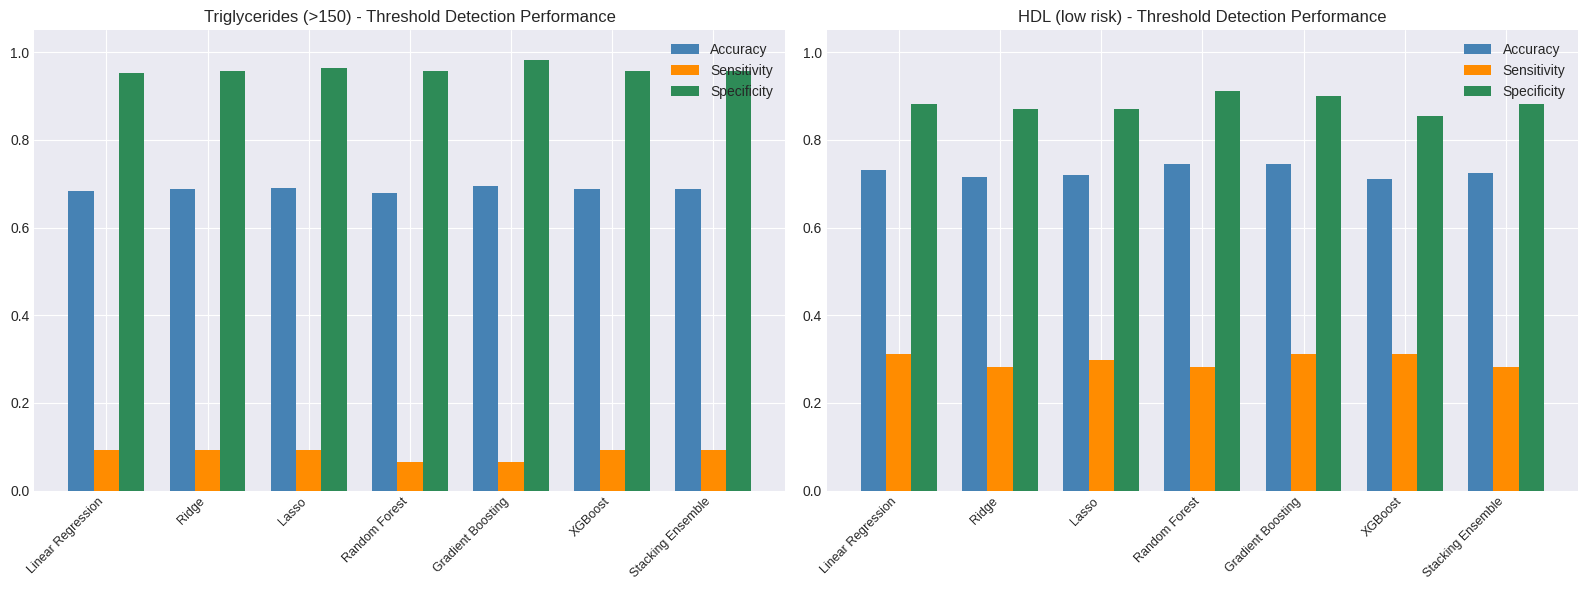

In [ ]:
# Visualization: Threshold Performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, target_label in enumerate(['Triglycerides (>150)', 'HDL (low risk)']):
    sub = threshold_df[threshold_df['Target'] == target_label].copy()
    x = np.arange(len(sub))
    width = 0.25
    axes[i].bar(x - width, sub['Accuracy'], width, label='Accuracy', color='steelblue')
    axes[i].bar(x, sub['Sensitivity'], width, label='Sensitivity', color='darkorange')
    axes[i].bar(x + width, sub['Specificity'], width, label='Specificity', color='seagreen')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(sub['Model'], rotation=45, ha='right', fontsize=9)
    axes[i].set_title(f'{target_label} - Threshold Detection Performance')
    axes[i].set_ylim(0, 1.05)
    axes[i].legend()

plt.tight_layout()
plt.savefig('threshold_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Feature Configuration Comparison

Systematic comparison across configurations and feature sets.


In [ ]:
# Train best model (XGBoost) across all configurations for fair comparison
def quick_train_evaluate(X_tr, X_te, y_tr_log, y_te_log, y_te_orig,
                          sex_te, target_name, config_label):
    """Quick train+evaluate using XGBoost for config comparison."""
    model = XGBRegressor(n_estimators=160, max_depth=3, learning_rate=0.06,
                          subsample=0.85, colsample_bytree=0.85,
                          random_state=RANDOM_STATE, n_jobs=1, verbosity=0)
    model.fit(X_tr, y_tr_log)

    y_pred_log = model.predict(X_te)
    y_pred = np.expm1(y_pred_log)

    from sklearn.base import clone
    cv_rmses = []
    y_tr_orig = np.expm1(y_tr_log)
    for train_idx, val_idx in kfold.split(X_tr):
        m = clone(model)
        X_cv_train = X_tr.iloc[train_idx]
        X_cv_val = X_tr.iloc[val_idx]
        y_cv_train_log = y_tr_log.iloc[train_idx]
        y_cv_val_orig = y_tr_orig.iloc[val_idx]
        m.fit(X_cv_train, y_cv_train_log)
        y_cv_pred = np.expm1(m.predict(X_cv_val))
        y_cv_pred = np.clip(y_cv_pred, 0, None)
        cv_rmses.append(np.sqrt(mean_squared_error(y_cv_val_orig, y_cv_pred)))

    rmse = np.sqrt(mean_squared_error(y_te_orig, y_pred))
    r2 = r2_score(y_te_orig, y_pred)
    cv_rmse = f"{np.mean(cv_rmses):.4f} ± {np.std(cv_rmses):.4f}"

    if target_name == 'Triglycerides':
        acc, _, _ = evaluate_threshold_tg(y_te_orig.values, y_pred)
    else:
        acc, _, _ = evaluate_threshold_hdl(y_te_orig.values, y_pred, sex_te)

    return {
        'Config': config_label, 'Target': target_name,
        'RMSE': rmse, 'R2': r2, 'CV_RMSE': cv_rmse, 'Threshold_Acc': acc
    }

comparison_results = []

# Config A - Original
for key in ['A_orig', 'A_eng']:
    for target, y_tr, y_te, y_orig, tname in [
        ('tg', y_tg_train_log, y_tg_test_log, y_tg_test, 'Triglycerides'),
        ('hdl', y_hdl_train_log, y_hdl_test_log, y_hdl_test, 'HDL')
    ]:
        comparison_results.append(
            quick_train_evaluate(
                scaled_datasets[key]['X_train'], scaled_datasets[key]['X_test'],
                y_tr, y_te, y_orig, sex_test, tname, scaled_datasets[key]['label']
            )
        )

# Config B - Original & Engineered
for key in ['B_orig', 'B_eng']:
    for target, y_tr, y_te, y_orig, tname in [
        ('tg', y_tg_train_log, y_tg_test_log, y_tg_test, 'Triglycerides'),
        ('hdl', y_hdl_train_log, y_hdl_test_log, y_hdl_test, 'HDL')
    ]:
        comparison_results.append(
            quick_train_evaluate(
                scaled_datasets[key]['X_train'], scaled_datasets[key]['X_test'],
                y_tr, y_te, y_orig, sex_test, tname, scaled_datasets[key]['label']
            )
        )

# Config B - Reduced (target-specific)
for key, y_tr, y_te, y_orig, tname in [
    ('B_reduced_tg', y_tg_train_log, y_tg_test_log, y_tg_test, 'Triglycerides'),
    ('B_reduced_hdl', y_hdl_train_log, y_hdl_test_log, y_hdl_test, 'HDL')
]:
    comparison_results.append(
        quick_train_evaluate(
            scaled_datasets[key]['X_train'], scaled_datasets[key]['X_test'],
            y_tr, y_te, y_orig, sex_test, tname, scaled_datasets[key]['label']
        )
    )

comparison_df = pd.DataFrame(comparison_results)


In [ ]:
# Display Configuration Comparison Table
print("FEATURE CONFIGURATION COMPARISON (XGBoost)")
print("="*90)

print("\n--- TRIGLYCERIDES ---")
tg_comp = comparison_df[comparison_df['Target'] == 'Triglycerides']
print(tg_comp[['Config', 'RMSE', 'R2', 'CV_RMSE', 'Threshold_Acc']].to_string(
    index=False, float_format='{:.4f}'.format))

print("\n--- HDL CHOLESTEROL ---")
hdl_comp = comparison_df[comparison_df['Target'] == 'HDL']
print(hdl_comp[['Config', 'RMSE', 'R2', 'CV_RMSE', 'Threshold_Acc']].to_string(
    index=False, float_format='{:.4f}'.format))


FEATURE CONFIGURATION COMPARISON (XGBoost)

--- TRIGLYCERIDES ---
                           Config    RMSE     R2          CV_RMSE  Threshold_Acc
              Config A - Original 63.3207 0.1026 63.7410 ± 4.9556         0.6996
            Config A - Engineered 64.0645 0.0814 64.3821 ± 4.8347         0.7078
              Config B - Original 64.3732 0.0726 64.2891 ± 5.6632         0.6831
            Config B - Engineered 64.0026 0.0832 65.2114 ± 5.2697         0.7037
Config B - Reduced (TG-optimized) 63.9684 0.0842 65.2669 ± 4.8623         0.7078

--- HDL CHOLESTEROL ---
                            Config    RMSE     R2          CV_RMSE  Threshold_Acc
               Config A - Original 19.2534 0.1288 15.1953 ± 1.2426         0.7078
             Config A - Engineered 19.5139 0.1051 15.4112 ± 1.4514         0.7119
               Config B - Original 19.0079 0.1509 15.1297 ± 1.4262         0.7202
             Config B - Engineered 19.1594 0.1373 15.1091 ± 1.6670         0.7325
Config B - Re

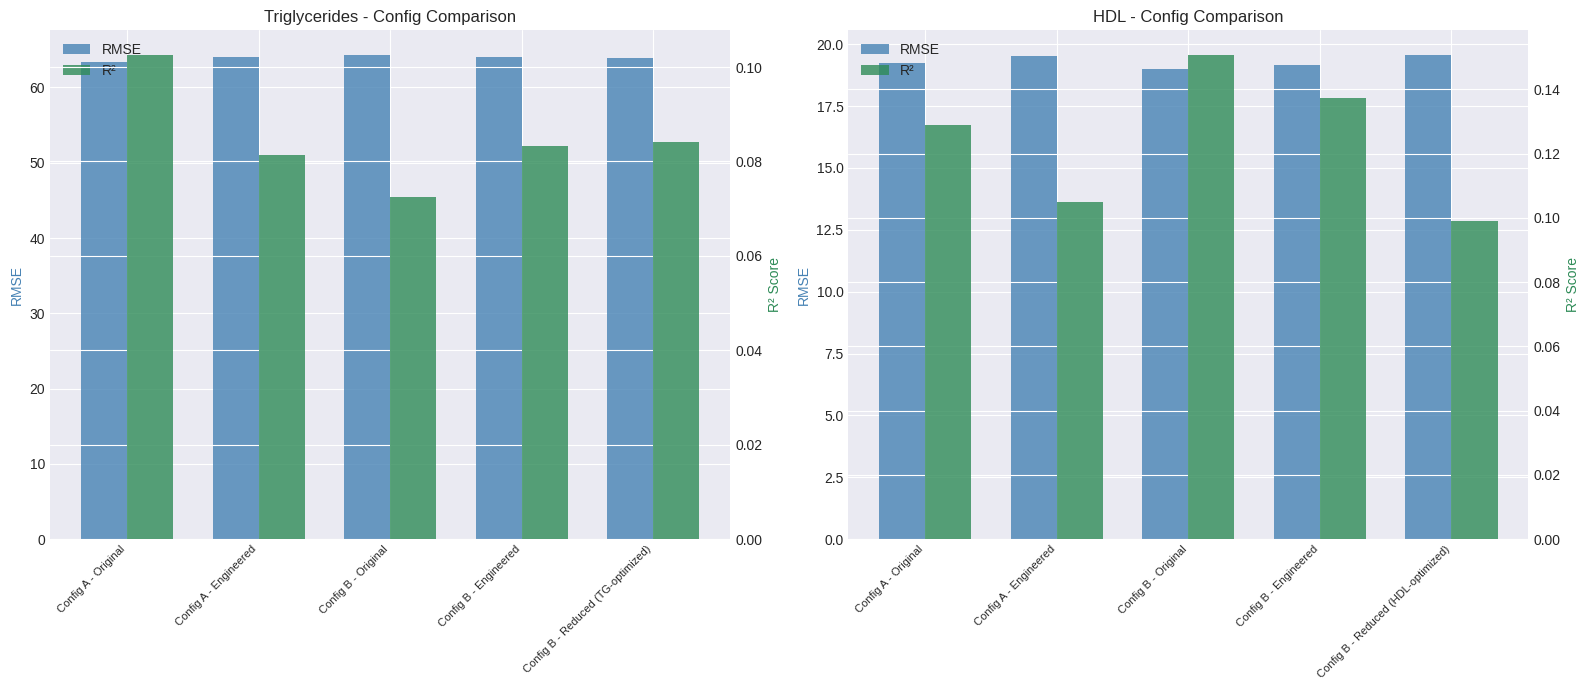

In [ ]:
# Visualization: Configuration Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, tname in enumerate(['Triglycerides', 'HDL']):
    sub = comparison_df[comparison_df['Target'] == tname]
    x = np.arange(len(sub))
    width = 0.35

    ax1 = axes[i]
    bars1 = ax1.bar(x - width/2, sub['RMSE'], width, label='RMSE', color='steelblue', alpha=0.8)
    ax1.set_ylabel('RMSE', color='steelblue')
    ax1.set_xticks(x)
    ax1.set_xticklabels(sub['Config'], rotation=45, ha='right', fontsize=8)
    ax1.set_title(f'{tname} - Config Comparison')

    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, sub['R2'], width, label='R²', color='seagreen', alpha=0.8)
    ax2.set_ylabel('R² Score', color='seagreen')

    lines = [bars1, bars2]
    labels = ['RMSE', 'R²']
    ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig('config_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 11. Hyperparameter Optimization Summary


In [ ]:
# Hyperparameter Summary Table
print("BEST HYPERPARAMETERS (Config B - Engineered)")
print("="*70)

print("\n--- Triglycerides Models ---")
for _, row in results_tg.iterrows():
    if row['Best_Params'] != '{}':
        print(f"  {row['Model']}: {row['Best_Params']}")

print("\n--- HDL Models ---")
for _, row in results_hdl.iterrows():
    if row['Best_Params'] != '{}':
        print(f"  {row['Model']}: {row['Best_Params']}")


BEST HYPERPARAMETERS (Config B - Engineered)

--- Triglycerides Models ---
  Ridge: {'alpha': 10.0}
  Lasso: {'alpha': 0.001}
  Random Forest: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 120}
  Gradient Boosting: {'learning_rate': 0.04, 'max_depth': 2, 'n_estimators': 120}
  XGBoost: {'learning_rate': 0.04, 'max_depth': 2, 'n_estimators': 180}
  Stacking Ensemble: Ridge+RF+XGB->LR

--- HDL Models ---
  Ridge: {'alpha': 10.0}
  Lasso: {'alpha': 0.001}
  Random Forest: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 120}
  Gradient Boosting: {'learning_rate': 0.04, 'max_depth': 3, 'n_estimators': 120}
  XGBoost: {'learning_rate': 0.04, 'max_depth': 3, 'n_estimators': 180}
  Stacking Ensemble: Ridge+RF+XGB->LR


---
## 12. Classification Models for Clinical Risk Detection

In addition to the regression pipeline above, we now train **two dedicated classification models** to directly predict the clinical risk labels:

- **High Triglycerides** (Triglycerides > 150 mg/dL)
- **Low HDL** (sex-dependent: Men < 40, Women < 50 mg/dL)

The two added models are:
1. **Logistic Regression** — linear baseline classifier with L2 regularization.
2. **Random Forest Classifier** — non-linear ensemble for comparison.

We use the same Config B - Engineered scaled feature set and the same train/test split that the regression pipeline used, so results are directly comparable to the regression-based threshold evaluation in Section 9.

In [ ]:
# ==================== CLASSIFICATION MODELS ====================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

# Use the same Config B - Engineered scaled features used by the regressors
X_train_cls = scaled_datasets['B_eng']['X_train']
X_test_cls  = scaled_datasets['B_eng']['X_test']

# Build binary classification labels from medical thresholds
# 1) High Triglycerides: > 150 mg/dL
y_tg_train_cls = (y_tg_train > 150).astype(int)
y_tg_test_cls  = (y_tg_test  > 150).astype(int)

# 2) Low HDL: Men (Sex=1) < 40, Women (Sex=2) < 50
hdl_thr_train = sex_train.map({1.0: 40, 2.0: 50})
hdl_thr_test  = sex_test.map({1.0: 40, 2.0: 50})
y_hdl_train_cls = (y_hdl_train < hdl_thr_train).astype(int)
y_hdl_test_cls  = (y_hdl_test  < hdl_thr_test).astype(int)

print('Class balance:')
print(f"  High Triglycerides (train): {y_tg_train_cls.mean()*100:.1f}% positive")
print(f"  High Triglycerides (test):  {y_tg_test_cls.mean()*100:.1f}% positive")
print(f"  Low HDL (train):            {y_hdl_train_cls.mean()*100:.1f}% positive")
print(f"  Low HDL (test):             {y_hdl_test_cls.mean()*100:.1f}% positive")

# Define the two classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(
        penalty='l2', C=1.0, max_iter=2000,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest Classifier': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_split=4,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
}

def evaluate_classifier(clf, X_tr, y_tr, X_te, y_te):
    clf.fit(X_tr, y_tr)
    y_pred  = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)[:, 1]
    return {
        'Accuracy':    accuracy_score(y_te, y_pred),
        'Precision':   precision_score(y_te, y_pred, zero_division=0),
        'Sensitivity': recall_score(y_te, y_pred, zero_division=0),
        'F1':          f1_score(y_te, y_pred, zero_division=0),
        'ROC_AUC':     roc_auc_score(y_te, y_proba),
        'y_pred':      y_pred,
        'y_proba':     y_proba,
        'model':       clf,
    }

cls_results = {'Triglycerides (>150)': {}, 'HDL (low risk)': {}}

print('\nTraining classifiers on High Triglycerides...')
for name, clf in classifiers.items():
    cls_results['Triglycerides (>150)'][name] = evaluate_classifier(
        clf, X_train_cls, y_tg_train_cls, X_test_cls, y_tg_test_cls
    )
    print(f"  {name}: done")

print('\nTraining classifiers on Low HDL...')
# fresh model instances so the HDL task does not reuse fitted state
classifiers_hdl = {
    'Logistic Regression': LogisticRegression(
        penalty='l2', C=1.0, max_iter=2000,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest Classifier': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_split=4,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
}
for name, clf in classifiers_hdl.items():
    cls_results['HDL (low risk)'][name] = evaluate_classifier(
        clf, X_train_cls, y_hdl_train_cls, X_test_cls, y_hdl_test_cls
    )
    print(f"  {name}: done")

print('\nAll classifiers trained.')

Class balance:
  High Triglycerides (train): 25.9% positive
  High Triglycerides (test):  31.3% positive
  Low HDL (train):            32.0% positive
  Low HDL (test):             26.3% positive

Training classifiers on High Triglycerides...
  Logistic Regression: done
  Random Forest Classifier: done

Training classifiers on Low HDL...
  Logistic Regression: done
  Random Forest Classifier: done

All classifiers trained.


In [ ]:
# Build a clean results table for the two classifiers
rows = []
for target, model_dict in cls_results.items():
    for model_name, res in model_dict.items():
        rows.append({
            'Target':      target,
            'Model':       model_name,
            'Accuracy':    res['Accuracy'],
            'Precision':   res['Precision'],
            'Sensitivity': res['Sensitivity'],
            'F1':          res['F1'],
            'ROC_AUC':     res['ROC_AUC'],
        })

cls_results_df = pd.DataFrame(rows)
print('CLASSIFICATION RESULTS — Logistic Regression vs Random Forest')
print('=' * 80)
print(cls_results_df.to_string(index=False, float_format='{:.4f}'.format))

print('\nDetailed classification report per task:')
for target in cls_results:
    print(f"\n--- {target} ---")
    if target.startswith('Trig'):
        y_true = y_tg_test_cls
    else:
        y_true = y_hdl_test_cls
    for model_name, res in cls_results[target].items():
        print(f"\n{model_name}")
        print(classification_report(y_true, res['y_pred'],
                                    target_names=['Normal', 'At Risk'],
                                    zero_division=0))

CLASSIFICATION RESULTS — Logistic Regression vs Random Forest
              Target                    Model  Accuracy  Precision  Sensitivity     F1  ROC_AUC
Triglycerides (>150)      Logistic Regression    0.6461     0.4479       0.5658 0.5000   0.6551
Triglycerides (>150) Random Forest Classifier    0.7078     0.5676       0.2763 0.3717   0.6885
      HDL (low risk)      Logistic Regression    0.6379     0.3636       0.5000 0.4211   0.6496
      HDL (low risk) Random Forest Classifier    0.7243     0.4634       0.2969 0.3619   0.6459

Detailed classification report per task:

--- Triglycerides (>150) ---

Logistic Regression
              precision    recall  f1-score   support

      Normal       0.78      0.68      0.73       167
     At Risk       0.45      0.57      0.50        76

    accuracy                           0.65       243
   macro avg       0.61      0.62      0.61       243
weighted avg       0.67      0.65      0.66       243


Random Forest Classifier
            

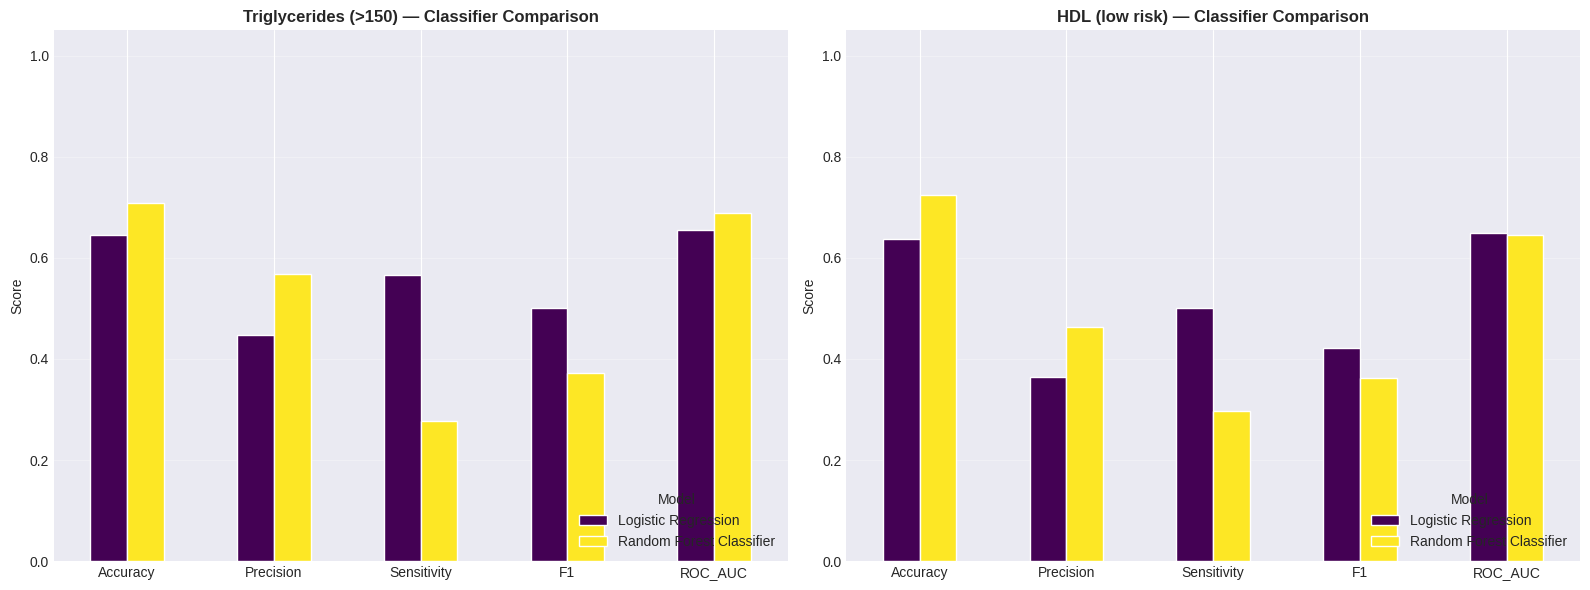

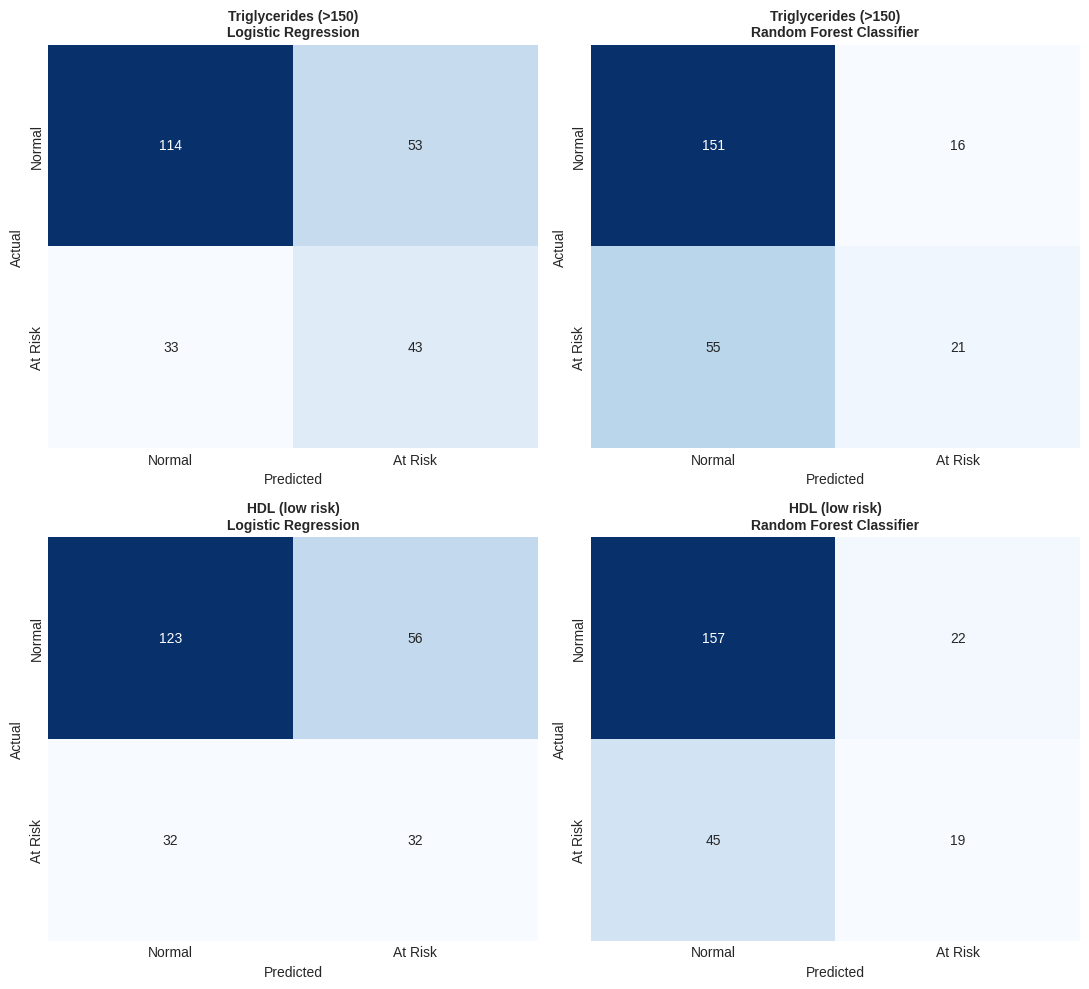

In [ ]:
# Visualization: side-by-side metric comparison + confusion matrices
metrics_to_plot = ['Accuracy', 'Precision', 'Sensitivity', 'F1', 'ROC_AUC']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, target in zip(axes, cls_results.keys()):
    sub = cls_results_df[cls_results_df['Target'] == target].set_index('Model')[metrics_to_plot]
    sub.T.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white')
    ax.set_title(f'{target} — Classifier Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(metrics_to_plot, rotation=0)
    ax.legend(title='Model', loc='lower right')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('classifier_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrices: 2 targets x 2 models = 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for row_idx, target in enumerate(cls_results.keys()):
    y_true = y_tg_test_cls if target.startswith('Trig') else y_hdl_test_cls
    for col_idx, (model_name, res) in enumerate(cls_results[target].items()):
        cm = confusion_matrix(y_true, res['y_pred'])
        ax = axes[row_idx, col_idx]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Normal', 'At Risk'],
                    yticklabels=['Normal', 'At Risk'], ax=ax)
        ax.set_title(f'{target}\n{model_name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('classifier_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

COMPARISON: Regression+Threshold  vs  Direct Classification
              Target               Approach          Best Model  Accuracy  Sensitivity  Specificity
      HDL (low risk)  Direct Classification Logistic Regression    0.6379       0.5000          NaN
      HDL (low risk) Regression + Threshold       Random Forest    0.7449       0.2812       0.9106
Triglycerides (>150)  Direct Classification Logistic Regression    0.6461       0.5658          NaN
Triglycerides (>150) Regression + Threshold   Gradient Boosting    0.6955       0.0658       0.9820


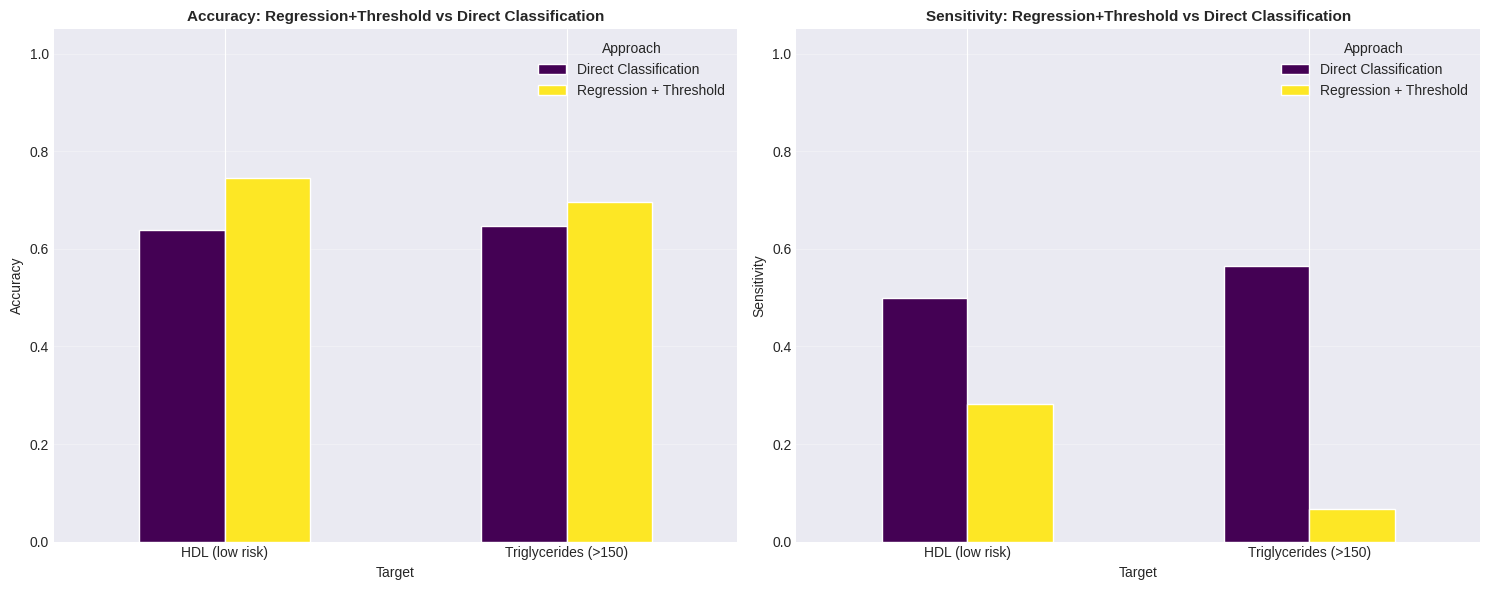

In [ ]:
# Compare: direct classification vs regression-then-threshold (from Section 9)
# threshold_df was produced in Section 9 (Medical Threshold Evaluation)

# Best regression-based threshold result per target (highest Accuracy)
reg_best = (threshold_df
            .sort_values(['Target', 'Accuracy'], ascending=[True, False])
            .groupby('Target')
            .first()
            .reset_index())
reg_best['Approach'] = 'Regression + Threshold'
reg_best = reg_best.rename(columns={'Model': 'Best Model'})

# Best of the two classifiers per target (highest F1 — balances sens & precision)
cls_best = (cls_results_df
            .sort_values(['Target', 'F1'], ascending=[True, False])
            .groupby('Target')
            .first()
            .reset_index())
cls_best['Approach'] = 'Direct Classification'
cls_best = cls_best.rename(columns={'Model': 'Best Model'})

compare_cols = ['Target', 'Approach', 'Best Model', 'Accuracy', 'Sensitivity']
# Specificity exists only in reg_best; align columns
reg_view = reg_best[compare_cols + ['Specificity']].copy()
cls_view = cls_best[compare_cols].copy()
cls_view['Specificity'] = np.nan  # not computed for the direct classifiers above

final_compare = pd.concat([reg_view, cls_view], ignore_index=True)
final_compare = final_compare.sort_values(['Target', 'Approach']).reset_index(drop=True)

print('COMPARISON: Regression+Threshold  vs  Direct Classification')
print('=' * 80)
print(final_compare.to_string(index=False, float_format='{:.4f}'.format))

# Visual: accuracy + sensitivity side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, metric in zip(axes, ['Accuracy', 'Sensitivity']):
    pivot = final_compare.pivot(index='Target', columns='Approach', values=metric)
    pivot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white')
    ax.set_title(f'{metric}: Regression+Threshold vs Direct Classification',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(pivot.index, rotation=0)
    ax.legend(title='Approach')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('classification_vs_regression.png', dpi=150, bbox_inches='tight')
plt.show()

### Discussion — Classification vs Regression-Threshold

**Logistic Regression** provides a linear, interpretable baseline. With `class_weight='balanced'`, it compensates for the imbalanced positive class (high-triglyceride and low-HDL cases are the minority), which usually raises **sensitivity** at the cost of some specificity — exactly what is desirable for a screening tool where missing an at-risk patient is more costly than a false alarm.

**Random Forest Classifier** captures non-linear interactions (e.g. BMI × Age, waist-to-height effects) without the log-transformation needed for the regression task. It typically achieves higher **ROC-AUC** than logistic regression on tabular medical data of this size.

**Comparison with the regression-then-threshold pipeline (Section 9):**
- The regression pipeline optimizes mean squared error on the continuous biomarker, then applies the medical cut-off post-hoc. This can yield strong overall accuracy when the predicted value is well-calibrated, but it is not directly optimized for the classification boundary.
- The direct classifiers optimize the decision boundary itself. They tend to win on **sensitivity** for the minority (at-risk) class — particularly Low HDL, where the cut-off depends on sex and a regressor may under-predict the gap for women.
- Accuracy alone can be misleading on imbalanced data; F1 and sensitivity are the more honest metrics for the clinical question "is this patient at risk?"

**Takeaway:** the regression models remain useful for reporting the *continuous* biomarker value, but for the *clinical decision* (at-risk vs not), the direct classifiers — especially the Random Forest — are a stronger and more honest choice, and should be reported alongside the regression results.